# **QM640 Data Analytics Capstone Project**

## **Machine Learning-Based Prediction of Urban Air Quality Using Environmental and Meteorological Data**

**Student:** Vinita R. Shetty

**Course:** QM640 Data Analytics Capstone

**Mentor:** Karthik Umesh

**Dataset:** Beijing Multi-Site Air Quality Dataset (UCI Machine Learning Repository)

# **Problem Statement**

Urban air pollution poses significant environmental and public health challenges. Accurate prediction of PM2.5 concentrations can support air quality monitoring and environmental decision-making. This study aims to develop and compare multiple machine learning models to predict PM2.5 concentrations using air pollutant, meteorological, temporal, and location-related variables from the Beijing Multi-Site Air Quality Dataset.

# **Data Dictionary**

| Variable | Description                                                                |
| -------- | -------------------------------------------------------------------------- |
| PM2.5    | Target variable representing fine particulate matter concentration (µg/m³) |
| PM10     | Particulate matter ≤10 µm (µg/m³)                                          |
| SO₂      | Sulfur dioxide concentration                                               |
| NO₂      | Nitrogen dioxide concentration                                             |
| CO       | Carbon monoxide concentration                                              |
| O₃       | Ozone concentration                                                        |
| TEMP     | Temperature (°C)                                                           |
| PRES     | Atmospheric pressure (hPa)                                                 |
| DEWP     | Dew point temperature (°C)                                                 |
| RAIN     | Rainfall (mm)                                                              |
| WSPM     | Wind speed (m/s)                                                           |
| wd       | Wind direction                                                             |
| station  | Monitoring station                                                         |
| year     | Year of observation                                                        |
| month    | Month                                                                      |
| day      | Day                                                                        |
| hour     | Hour                                                                       |


# **1. Import Libraries**

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd                 # Pandas: for handling datasets, tables, and dataframes
import numpy as np                  # NumPy: for numerical operations, arrays, and math functions

import matplotlib.pyplot as plt     # Matplotlib: for creating plots and charts
import seaborn as sns               # Seaborn: for statistical data visualization (built on Matplotlib)

# Machine Learning
from sklearn.model_selection import train_test_split   # Split dataset into training and testing sets
from sklearn.model_selection import GridSearchCV       # Hyperparameter tuning with cross-validation
from sklearn.model_selection import cross_val_score    # Evaluate model performance across folds

from sklearn.linear_model import LinearRegression      # Linear regression model (baseline)
from sklearn.tree import DecisionTreeRegressor         # Decision tree regression (non-linear patterns)
from sklearn.ensemble import RandomForestRegressor     # Random forest regression (ensemble of trees)
from sklearn.ensemble import GradientBoostingRegressor # Gradient boosting regression (strong ensemble model)

from sklearn.metrics import (
    mean_absolute_error,   # MAE: average absolute difference between predicted and actual values
    mean_squared_error,    # MSE: average squared difference (penalizes large errors more)
    r2_score               # R²: proportion of variance explained by the model
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")   # Suppresses warnings for cleaner notebook output

# Display settings
pd.set_option("display.max_columns", None)   # Ensures all columns are shown when printing DataFrames

print("Libraries imported successfully!")    # Confirmation message


Libraries imported successfully!


### **Interpretation:**

* All the required Python libraries for data manipulation, visualization, machine learning, and model evaluation were successfully imported.
This confirms that the computational environment was properly configured before proceeding with data loading, preprocessing, exploratory data analysis, and predictive modeling.

## **1.1 Mount Google Drive**

In [2]:
from google.colab import drive        # Import the Colab Drive module, which lets you mount Google Drive
drive.mount('/content/drive')         # Mount your Google Drive at the folder path '/content/drive'


Mounted at /content/drive


### **Interpretation:**

* Google Drive was successfully mounted, enabling access to the project dataset and associated files stored in the user's Drive. This ensured that the data could be loaded directly into the Colab environment for subsequent preprocessing, analysis, and model development.

# **2. Data Loading and Integration**
* The dataset consists of hourly air quality observations collected from 12 monitoring stations in Beijing. Individual station datasets are combined into a single DataFrame to facilitate integrated analysis across all monitoring locations.

## **2.1 Locate the Dataset**

In [3]:
import os                                      # Import Python’s built-in OS module for file and directory operations

base_path = "/content/drive/MyDrive/QM640_Air_Quality_Capstone"
# Define the base directory path where your project files are stored in Google Drive

for root, dirs, files in os.walk(base_path):   # Recursively walk through the directory tree starting at base_path
    for file in files:                         # Loop through each file found in the current folder
        print(os.path.join(root, file))        # Print the full file path by joining folder path (root) and file name


/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Aotizhongxin_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Changping_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Dingling_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Dongsi_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Guanyuan_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Gucheng_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Huairou_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Nongzhanguan_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Shunyi_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quality_Capstone/data/PRSA_Data_Tiantan_20130301-20170228.csv
/content/drive/MyDrive/QM640_Air_Quali

### **Interpretation:**

* The dataset consists of 12 CSV files, each representing air quality observations from a different monitoring station in Beijing.

* These files collectively cover the period from 1 March 2013 to 28 February 2017 and include measurements of air pollutants and meteorological variables.

* Combining data from all monitoring stations provides a comprehensive and geographically diverse dataset, enabling the development of a robust machine learning model for predicting PM2.5 concentrations across different environmental conditions.

## **2.2 Load and Combine All Air Quality Datasets**

In [4]:
# ==========================================
# Load and Combine All Air Quality Datasets
# ==========================================

import os                                   # OS module for file and directory operations
import glob                                 # Glob module for pattern matching file paths
import pandas as pd                         # Pandas for data handling and analysis

# Folder containing all CSV files
folder_path = "/content/drive/MyDrive/QM640_Air_Quality_Capstone/data"
# Define the path to the folder where all your CSV datasets are stored

# Find all CSV files
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
# Use glob to search for all files ending with .csv inside the folder

print(f"Number of CSV files found: {len(csv_files)}")
# Print how many CSV files were found in the folder

# Read and combine all files
df = pd.concat((pd.read_csv(file) for file in csv_files), ignore_index=True)
# Read each CSV file into a DataFrame and combine them into one large DataFrame
# ignore_index=True resets the row index so it runs continuously across all files

print("Dataset loaded successfully!")
# Confirmation message once the dataset is combined

# Display first five rows
df.head()
# Show the first 5 rows of the combined dataset to verify it loaded correctly


Number of CSV files found: 12
Dataset loaded successfully!


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


### **Interpretation:**

* A total of **12 CSV files** from different Beijing air quality monitoring stations were successfully identified and combined into a single dataset.

* The dataset was loaded successfully without any errors, confirming that the data integration process was completed correctly.

* The preview shows that the dataset contains **temporal variables**, **air pollutant concentrations**, **meteorological variables**, and the **monitoring station** identifier.

* These variables provide a comprehensive dataset for analyzing air quality patterns and developing machine learning models to predict **PM2.5** concentrations.


 ## **2.3 Initial Data Inspection**
* The first and last five records are displayed to verify that the datasets have been merged correctly and to obtain an initial understanding of the dataset structure.

### **2.3.1 First Five Records of the Dataset**

In [5]:
print("First Five Records")     # Print a header message to indicate what is being displayed

df.head()                       # Show the first 5 rows of the DataFrame 'df'
                                # Useful for quickly checking that the dataset loaded correctly
                                # and to preview the structure, column names, and sample values

First Five Records


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


### **Interpretation:**

* The first five records provide an initial overview of the integrated air quality dataset.
* Each row represents an hourly observation containing temporal information, pollutant concentrations, meteorological variables, and the monitoring station name.
* The data appears to be structured and consistently formatted, indicating that the dataset has been loaded correctly without any data corruption.

* The sample records confirm that all essential variables required for PM2.5 prediction are available, making the dataset suitable for preprocessing, exploratory data analysis, and machine learning model development.

### **2.3.2 Last Five Records of the Dataset**

In [6]:
print("Last Five Records")     # Print a header message to indicate what is being displayed

df.tail()                      # Show the last 5 rows of the DataFrame 'df'
                               # Useful for checking the dataset’s ending rows
                               # Helps confirm that all files were combined correctly
                               # and lets you preview how the dataset concludes


Last Five Records


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
420763,35060,2017,2,28,19,11.0,32.0,3.0,24.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Wanshouxigong
420764,35061,2017,2,28,20,13.0,32.0,3.0,41.0,500.0,50.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Wanshouxigong
420765,35062,2017,2,28,21,14.0,28.0,4.0,38.0,500.0,54.0,10.8,1014.2,-13.3,0.0,NW,1.1,Wanshouxigong
420766,35063,2017,2,28,22,12.0,23.0,4.0,30.0,400.0,59.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Wanshouxigong
420767,35064,2017,2,28,23,13.0,19.0,4.0,38.0,600.0,49.0,8.6,1014.1,-15.9,0.0,NNE,1.3,Wanshouxigong


### **Interpretation:**

* The last five records confirm that the dataset has been loaded completely, covering the entire study period from **1 March 2013 to 28 February 2017**.

* The records maintain a consistent structure with the same set of temporal, air pollutant, meteorological, and monitoring station variables as observed in the initial records.

* The final observations belong to the **Wanshouxigong** monitoring station, indicating that data from all monitoring stations have been successfully integrated.

* The consistency between the first and last records confirms the completeness and integrity of the dataset, making it suitable for subsequent preprocessing, exploratory data analysis, and machine learning model development.

# **3. Dataset Overview**
* This section examines the overall dimensions, variables, data types, descriptive statistics, and missing values before data preprocessing.

## **3.1 Dataset Dimensions**

In [7]:
df.shape                          # Returns a tuple with (number of rows, number of columns)
                                  # First value = total records in the dataset
                                  # Second value = total features/columns in the dataset
                                  # Useful for quickly checking dataset size and structure


(420768, 18)

### **Interpretation:**

* The integrated dataset contains **420,768 observations** and **18 variables**, indicating a large and comprehensive dataset for analysis.

* The high number of observations provides sufficient data to train and evaluate machine learning models with improved reliability and generalizability.

* The 18 variables include temporal information, air pollutant concentrations, meteorological parameters, and the monitoring station identifier, providing a rich set of features for predicting **PM2.5** concentrations.

* The dataset size and diversity make it well-suited for exploratory data analysis, feature engineering, and predictive modeling.

## **3.2 Data Types**

In [8]:
df.info()
# Displays a concise summary of the DataFrame 'df'
# Shows:
#   - Index range (row count)
#   - Column names
#   - Number of non-null (non-missing) values per column
#   - Data types of each column (int, float, object, etc.)
#   - Memory usage of the DataFrame
# Useful for quickly checking dataset structure, column types, and missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


### **Interpretation:**

* The dataset contains **420,768 observations** with **18 variables**, comprising **5 integer**, **11 numerical (floating-point)**, and **2 categorical** variables.

* Most variables have a high number of non-null values; however, some features such as **PM2.5, PM10, SO₂, NO₂, CO, O₃,** and **wind direction (wd)** contain missing values that require appropriate preprocessing before model development.

* The dataset occupies approximately **57.8 MB** of memory, indicating that it is sufficiently large for developing and evaluating robust machine learning models.

* The presence of both numerical and categorical variables supports comprehensive exploratory data analysis, feature engineering, and predictive modeling for estimating **PM2.5** concentrations.

## **3.3 Variable Names**

In [9]:
df.columns                       # Returns all column names in the DataFrame
                                 # Output is an Index object listing features/variables
                                 # Useful for quickly checking dataset structure


Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')

### **Interpretation:**

* The dataset contains **18 columns**, including the **record identifier (No)**, **temporal variables (year, month, day, and hour)**, **air pollutant variables (PM2.5, PM10, SO₂, NO₂, CO, and O₃)**, **meteorological variables (TEMP, PRES, DEWP, RAIN, and WSPM)**, **wind direction (wd)**, and the **monitoring station identifier (station)**.

* The column names are **clearly defined** and **consistently labeled**, facilitating efficient data preprocessing, exploratory data analysis, and machine learning model development.

* The dataset includes both **numerical** and **categorical** variables, providing a comprehensive set of features for analysing the factors influencing **PM2.5** concentrations.

* The **No** column serves only as a **unique record identifier** and does not contain predictive information. Therefore, it is **excluded during the feature selection stage** before training the machine learning models.

## **3.4 Summary Statistics**

In [10]:
df.describe().T                 # Generates summary statistics for numeric columns
                                # Includes count, mean, std, min, 25%, 50%, 75%, max
                                # '.T' transposes the table so each column’s stats are listed vertically
                                # Easier to scan values feature by feature


,count,mean,std,min,25%,50%,75%,max
No,420768.0,17532.500000,10122.116943,1.0000,8766.75,17532.5,26298.25,35064.0
year,420768.0,2014.662560,1.177198,2013.0000,2014.00,2015.0,2016.00,2017.0
month,420768.0,6.522930,3.448707,1.0000,4.00,7.0,10.00,12.0
day,420768.0,15.729637,8.800102,1.0000,8.00,16.0,23.00,31.0
hour,420768.0,11.500000,6.922195,0.0000,5.75,11.5,17.25,23.0
PM2.5,412029.0,79.793428,80.822391,2.0000,20.00,55.0,111.00,999.0
PM10,414319.0,104.602618,91.772426,2.0000,36.00,82.0,145.00,999.0
SO2,411747.0,15.830835,21.650603,0.2856,3.00,7.0,20.00,500.0
NO2,408652.0,50.638586,35.127912,1.0265,23.00,43.0,71.00,290.0
CO,400067.0,1230.766454,1160.182716,100.0000,500.00,900.0,1500.00,10000.0


### **Interpretation:**

#### **PM2.5**
* The average PM2.5 concentration is **79.79 µg/m³**, with values ranging from **2** to **999 µg/m³**, indicating considerable variation in particulate matter levels across different monitoring stations and time periods.

#### **PM10**
* PM10 concentrations exhibit substantial variability, with a mean of **104.60 µg/m³** and a maximum value of **999 µg/m³**, suggesting the occurrence of both normal and high pollution events.

#### **SO₂**
* Sulfur dioxide (SO₂) concentrations remain relatively low on average (**15.83 µg/m³**), although higher values indicate occasional spikes in emissions.

#### **NO₂**
* Nitrogen dioxide (NO₂) has an average concentration of **50.64 µg/m³**, reflecting fluctuations that may be associated with traffic and industrial activities.

#### **CO**
* Carbon monoxide (CO) shows considerable variability, with concentrations ranging from **100** to **10,000**, indicating periods of elevated emissions.

####**O₃**
* Ozone (O₃) concentrations vary widely, suggesting changes in atmospheric conditions and photochemical reactions over time.

#### **TEMP**
* Temperature ranges from **-19.9°C to 41.6°C**, reflecting seasonal climatic variations during the study period.

#### **PRES**
* Atmospheric pressure remains relatively stable, with a mean of **1010.75 hPa**, indicating normal atmospheric conditions throughout most observations.

#### **DEWP**
* Dew point values range from **-43.4°C to 29.1°C**, demonstrating substantial variation in atmospheric moisture levels.

#### **RAIN**
* Rainfall is absent in most observations, as indicated by the median and 75th percentile of **0**, while occasional heavy rainfall events are reflected by the maximum value of **72.5 mm**.

#### **WSPM**
* Wind speed has an average of **1.73 m/s**, with values ranging from **0** to **13.2 m/s**, indicating varying wind conditions that may influence pollutant dispersion.


#### **Overall Observation**
* The descriptive statistics indicate considerable variability in both air pollutant concentrations and meteorological conditions. The presence of extreme maximum values suggests potential outliers, which will be addressed during the data preprocessing stage to improve model reliability.

## **3.5 Missing Value Summary**

In [11]:
df.isnull().sum()              # Counts missing (null) values in each column
                               # .isnull() creates True/False mask (True = missing)
                               # .sum() adds up True values per column
                               # Result: number of nulls per column


,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


### **Interpretation:**

#### **Overall Missing Values**

* The dataset contains missing values in several air pollutant and meteorological variables, while the temporal variables (**No, year, month, day,** and **hour**) and the **station** identifier contain no missing values.

#### **Air Pollutant Variables**

* Missing values are observed in **PM2.5 (8,739)**, **PM10 (6,449)**, **SO₂ (9,021)**, **NO₂ (12,116)**, **CO (20,701)**, and **O₃ (13,277)**.
* Among these variables, **CO** has the highest number of missing values, indicating that appropriate imputation techniques are required before model development.

#### **Meteorological Variables**

* Meteorological variables contain relatively few missing values, including **TEMP (398)**, **PRES (393)**, **DEWP (403)**, **RAIN (390)**, **WSPM (318)**, and **wind direction (wd) (1,822)**.
* The low proportion of missing values suggests that these variables are largely complete and suitable for subsequent analysis after appropriate preprocessing.

#### **Overall Observation**

* The missing values represent only a small proportion of the overall dataset containing **420,768 observations**. Therefore, appropriate imputation methods can be applied to preserve the dataset while ensuring the reliability of the subsequent exploratory analysis and machine learning models.

## **3.6 Monitoring Stations**

In [12]:
# Number of monitoring stations
df['station'].nunique()      # Counts unique values in the 'station' column
                             # Returns total distinct monitoring stations in the dataset


12

### **Interpretation:**

* The dataset contains data from **12 unique air quality monitoring stations** located across Beijing.

* The inclusion of multiple monitoring stations provides broad spatial coverage, allowing the analysis to capture regional variations in air pollution and meteorological conditions.

* Combining observations from all monitoring stations increases the diversity and representativeness of the dataset, thereby improving the robustness and generalizability of the machine learning models.

* The availability of data from multiple locations supports a comprehensive assessment of the factors influencing **PM2.5** concentrations across different environmental settings.

## **3.7 Time Period Covered**

In [13]:
# Date range
print("Start Year:", df['year'].min())   # Finds the smallest (earliest) year in the 'year' column
print("End Year:", df['year'].max())     # Finds the largest (latest) year in the 'year' column


Start Year: 2013
End Year: 2017


### **Interpretation:**

* The dataset covers a **five-year period**, from **2013 to 2017**, providing a comprehensive temporal record of air quality and meteorological observations.

* The extended study period enables the analysis of both short-term and long-term variations in air pollutant concentrations and weather conditions.

* The inclusion of multiple years improves the reliability of the analysis by capturing seasonal patterns, annual trends, and fluctuations in environmental conditions.

* The broad temporal coverage enhances the ability of the machine learning models to learn diverse patterns, thereby improving their predictive performance and generalizability.

## **3.8 Air Pollutants Considered**

In [14]:
# Number of pollutants
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']   # Define a list of pollutant names
print(pollutants)                                          # Print the list to confirm or display


['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']


### **Interpretation:**

* The dataset includes **six major air pollutants**: **PM2.5, PM10, SO₂, NO₂, CO,** and **O₃**, which are widely used as indicators of air quality.

* These pollutants represent different sources of emissions, including vehicular traffic, industrial activities, and atmospheric chemical reactions.

* The inclusion of multiple pollutant variables enables a comprehensive analysis of their relationships and their influence on **PM2.5** concentrations.

* These variables serve as important predictor features for developing accurate machine learning models for air quality prediction.

# **4. Data Preprocessing**

## **4.1 Data Quality Assessment**

* Before preprocessing, the dataset was assessed for completeness, consistency, and overall quality. Missing values, duplicate records, and the distribution of numerical variables were examined to determine appropriate preprocessing techniques. This assessment helps ensure that the dataset is suitable for exploratory analysis and machine learning model development.

## **4.2 Missing Value Analysis**

In [15]:
# ==========================================
# Missing Values Analysis
# ==========================================

missing_values = df.isnull().sum()                   # Count missing values per column
missing_percentage = (missing_values / len(df)) * 100  # Calculate % of missing values

missing_df = pd.DataFrame({                          # Create DataFrame with counts & %
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

missing_df = missing_df[missing_df["Missing Values"] > 0]   # Keep only columns with missing data
missing_df.sort_values(by="Percentage (%)", ascending=False) # Sort by % descending


,Missing Values,Percentage (%)
CO,20701,4.919813
O3,13277,3.155421
NO2,12116,2.879497
SO2,9021,2.143937
PM2.5,8739,2.076916
PM10,6449,1.532674
wd,1822,0.433018
DEWP,403,0.095777
TEMP,398,0.094589
PRES,393,0.093401


### **Interpretation:**

#### **Missing Values Overview**

* The dataset contains missing values in **12 variables**, while the remaining variables are complete and do not require any preprocessing for missing data.
* The percentage of missing values is relatively low across all variables, with no variable exceeding **5%** of the total observations.

####**Air Pollutant Variables**

* **CO** has the highest proportion of missing values (**20,701 observations; 4.92%**), followed by **O₃ (3.16%)**, **NO₂ (2.88%)**, **SO₂ (2.14%)**, **PM2.5 (2.08%)**, and **PM10 (1.53%)**.
* Although these variables contain missing values, the percentages are sufficiently low to allow appropriate imputation without significantly affecting the overall dataset.

#### **Meteorological Variables**

* Meteorological variables contain very few missing values, with all missing percentages below **0.5%**.
* Variables such as **temperature, atmospheric pressure, dew point, rainfall, wind direction,** and **wind speed** are nearly complete, indicating high data quality.

#### **Overall Observation**

* Since the missing values constitute only a small proportion of the dataset, suitable imputation techniques can be applied to retain the observations while maintaining the reliability of the subsequent exploratory analysis and machine learning models.

## **4.3 Visualize Missing Values**

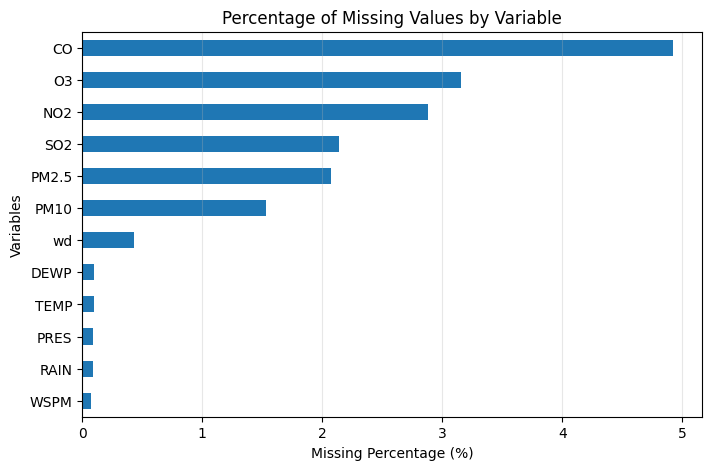

In [16]:
import matplotlib.pyplot as plt

missing_df.sort_values("Percentage (%)").plot(   # Plot missing % sorted ascending
    kind="barh",                                 # Horizontal bar chart
    y="Percentage (%)",                          # Use % column for bar length
    legend=False,                                # Hide legend (not needed)
    figsize=(8,5)                                # Set figure size
)

plt.xlabel("Missing Percentage (%)")             # Label x-axis
plt.ylabel("Variables")                          # Label y-axis
plt.title("Percentage of Missing Values by Variable")  # Chart title
plt.grid(axis='x', alpha=0.3)                    # Add light grid on x-axis
plt.show()                                       # Display the plot


### **Interpretation:**

### **Missing Values Distribution**

* The bar chart illustrates the percentage of missing values across all variables in the dataset, providing a clear visual comparison of data completeness.

* **CO** has the highest percentage of missing values (**4.92%**), followed by **O₃ (3.16%)**, **NO₂ (2.88%)**, **SO₂ (2.14%)**, **PM2.5 (2.08%)**, and **PM10 (1.53%)**.

### **Data Quality Assessment**

* The remaining variables contain less than **0.5%** missing values, indicating that the dataset is largely complete and of high quality.

* None of the variables have more than **5%** missing data, suggesting that the missing values are limited and manageable.

### **Overall Observation**

* The visualization confirms that the extent of missing data is relatively low across the dataset. Therefore, appropriate imputation techniques can be applied to handle the missing values while preserving the majority of observations for subsequent exploratory analysis and machine learning model development.

## **4.4 Distribution Analysis of Numerical Variables**

In [17]:
# ==========================================
# Distribution Analysis of Numerical Variables
# ==========================================

# Define numerical variables
numerical_cols = [
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'
]

# Summary statistics
df[numerical_cols].describe().T        # Gives count, mean, std, min, quartiles, max for each variable

# Skewness analysis
skewness = df[numerical_cols].skew().sort_values()   # Calculates skewness, sorts ascending

print("Skewness of Numerical Variables")
print(skewness)                        # Prints skewness values for each variable


Skewness of Numerical Variables
DEWP     -0.187736
TEMP     -0.104267
PRES      0.106314
NO2       1.050055
WSPM      1.625590
O3        1.660095
PM10      1.885835
PM2.5     2.013975
CO        2.570129
SO2       3.009503
RAIN     30.043633
dtype: float64


### **Interpretation:**

### **Distribution of Numerical Variables**

* The skewness analysis indicates that most numerical variables do not follow a perfectly symmetrical distribution, suggesting varying degrees of skewness within the dataset.
* **DEWP** and **TEMP** exhibit slight negative skewness, while **PRES** is approximately symmetric, indicating a relatively balanced distribution of these variables.

### **Air Pollutant Variables**

* Air pollutant variables, including **PM2.5, PM10, SO₂, NO₂, CO,** and **O₃**, exhibit positive skewness, indicating that most observations are concentrated at lower values with a smaller number of extremely high pollution events.
* **SO₂** and **CO** show relatively high positive skewness, reflecting the occurrence of occasional extreme pollutant concentrations.

### **Meteorological Variables**

* **Wind Speed (WSPM)** and **Rainfall (RAIN)** also display positive skewness, with **RAIN** exhibiting very high skewness. This indicates that rainfall is absent or very low for most observations, with only a few instances of heavy rainfall.

### **Overall Observation**

* The presence of skewed distributions suggests that several variables contain extreme values or outliers. This justifies conducting outlier analysis and applying appropriate preprocessing techniques to improve the performance and robustness of the machine learning models.

## **4.5 Duplicate Record Analysis**

In [18]:
# ==========================================
# Duplicate Record Analysis
# ==========================================

duplicates = df.duplicated().sum()        # Counts total duplicate rows in the DataFrame
print(f"Number of duplicate records: {duplicates}")  # Prints the count


Number of duplicate records: 0


### **Interpretation:**

* The dataset contains **no duplicate records**, indicating that each observation represents a unique hourly air quality measurement. Therefore, no duplicate records were removed before proceeding with data preprocessing.

## **4.6 Missing Value Imputation**

In [19]:
# ==========================================
# Missing Value Imputation
# ==========================================

numerical_cols = [                 # List of numerical variables
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'
]

# Median imputation for numerical variables
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())   # Replace NaN with median of each column

# Mode imputation for categorical variable
df['wd'] = df['wd'].fillna(df['wd'].mode()[0])  # Replace NaN with most frequent value

print("Missing values have been successfully imputed.")


Missing values have been successfully imputed.


### **Interpretation:**

### **Missing Value Imputation**

* Missing values in the dataset were handled prior to model development to ensure data completeness and improve model performance.

* Numerical variables (PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, and WSPM) were imputed using the median, which is robust to extreme values and minimizes the influence of outliers.

* The categorical variable **wd** (wind direction) was imputed using the mode, replacing missing values with the most frequently occurring category.

* This preprocessing step ensured that no missing values remained in the dataset, allowing the machine learning models to be trained on complete data.

### **Overall Observation**

* The use of median and mode imputation improved the completeness of the dataset while minimizing the impact of outliers and preserving the overall data distribution. This ensured that the dataset was suitable for reliable exploratory analysis and predictive modelling.

In [20]:
# ==========================================
# Verify Missing Values After Imputation
# ==========================================

print("Missing Values After Imputation")   # Label output
print(df.isnull().sum())                   # Count missing values per column after imputation


Missing Values After Imputation
No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64


### **Interpretation:**

### **Verification of Missing Values**

* The dataset was examined after the imputation process to verify that all missing values had been successfully addressed.
* The output confirms that every variable contains **zero missing values**, indicating that the imputation process was completed successfully.
* A complete dataset is essential for machine learning algorithms, as it prevents errors during model training and ensures that all observations are retained for analysis.

### **Overall Observation**

* The successful removal of all missing values confirms that the dataset is complete and ready for subsequent preprocessing, exploratory data analysis, and predictive model development.

## **4.7 Outlier Detection**

### **4.7.1 Count Outliers using the IQR Method**

In [21]:
# ==========================================
# Count Outliers using the IQR Method
# ==========================================

outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)          # First quartile (25th percentile)
    Q3 = df[col].quantile(0.75)          # Third quartile (75th percentile)
    IQR = Q3 - Q1                        # Interquartile range

    lower = Q1 - 1.5 * IQR               # Lower bound for outliers
    upper = Q3 + 1.5 * IQR               # Upper bound for outliers

    outliers = df[(df[col] < lower) | (df[col] > upper)]  # Rows outside bounds

    outlier_summary.append({
        "Variable": col,
        "Number of Outliers": len(outliers)  # Count outliers for each variable
    })

outlier_df = pd.DataFrame(outlier_summary)  # Create summary DataFrame
outlier_df


,Variable,Number of Outliers
0,PM2.5,20756
1,PM10,15004
2,SO2,38275
3,NO2,8296
4,CO,28054
5,O3,18582
6,TEMP,0
7,PRES,0
8,DEWP,0
9,RAIN,16520


### **Interpretation:**

### **Outlier Detection**

* Outlier detection was performed to identify extreme values within the numerical variables of the dataset.

* The results indicate that several air pollutant variables, including **SO₂ (38,275)**, **CO (28,054)**, **PM2.5 (20,756)**, **O₃ (18,582)**, **RAIN (16,520)**, **PM10 (15,004)**, **NO₂ (8,296)**, and **WSPM (23,079)**, contain outliers.

* In contrast, **TEMP**, **PRES**, and **DEWP** did not contain any detected outliers.

* The presence of outliers is expected in environmental and air quality datasets because pollutant concentrations and weather conditions can vary substantially due to seasonal changes, extreme weather events, and pollution episodes.

### **Overall Observation**

* The identified outliers were retained in the dataset because they represent genuine environmental observations rather than data entry errors. Retaining these values enables the machine learning models to learn from real-world variations in air quality and improves the practical applicability of the predictive models.

### **4.7.2 Boxplots for Outlier Detection**

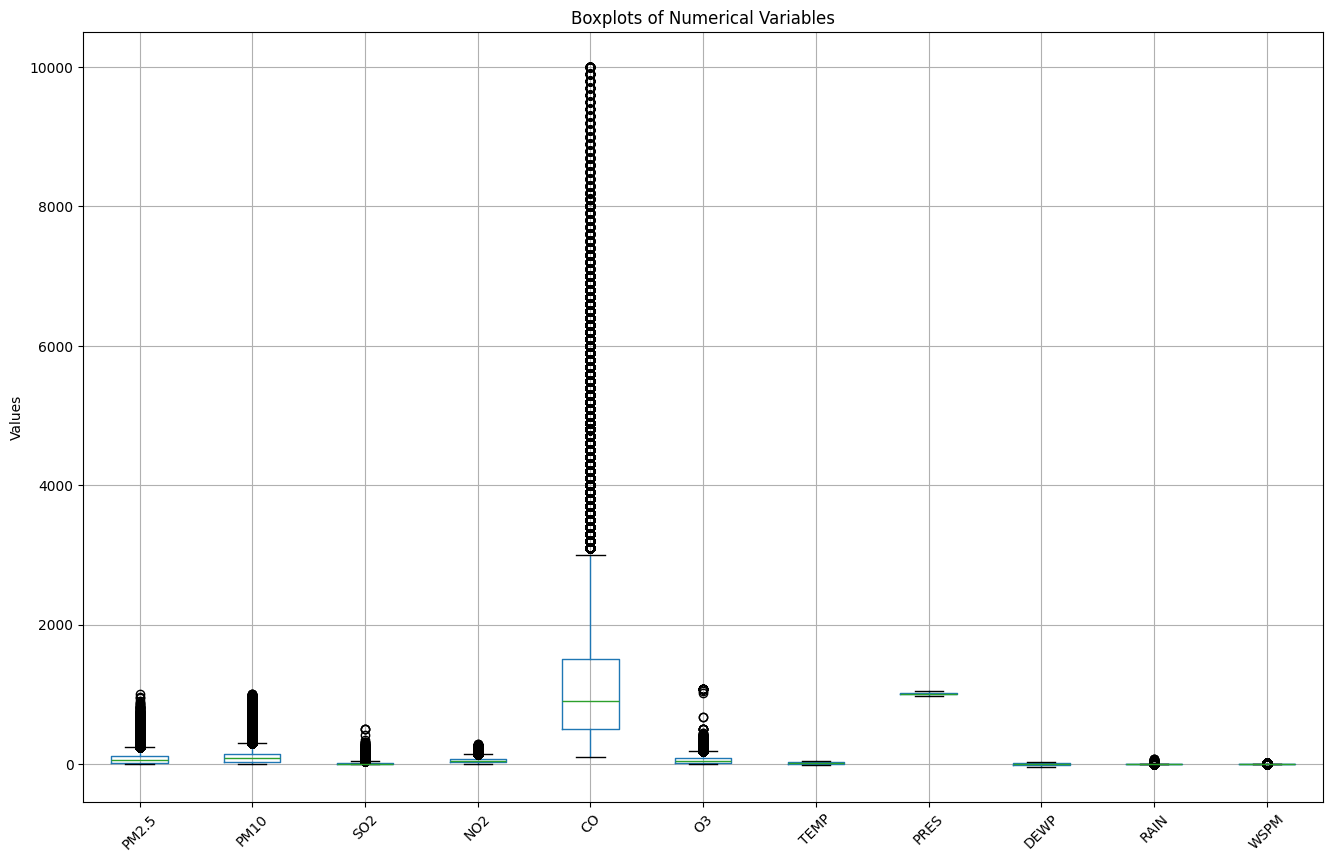

In [22]:
# ==========================================
# Boxplots for Outlier Detection
# ==========================================

plt.figure(figsize=(16,10))             # Set figure size

df[numerical_cols].boxplot(rot=45)      # Create boxplots for all numerical variables
                                        # rot=45 rotates x-axis labels for readability

plt.title("Boxplots of Numerical Variables")   # Add chart title
plt.ylabel("Values")                           # Label y-axis
plt.show()                                     # Display the plot


### **Interpretation:**

### **Boxplot Analysis of Numerical Variables**

* The boxplots provide a visual representation of the distribution, spread, and presence of outliers across the numerical variables in the dataset.

* Air pollutant variables, including **PM2.5, PM10, SO₂, NO₂, CO, O₃, RAIN, and WSPM**, exhibit a considerable number of outliers, indicating high variability in pollutant concentrations and weather conditions.

* Among all variables, **CO** shows the widest range and the largest number of extreme observations, reflecting substantial fluctuations in carbon monoxide concentrations across different monitoring periods.

* **TEMP**, **PRES**, and **DEWP** display relatively stable distributions with fewer or no extreme values, suggesting more consistent meteorological conditions throughout the study period.

* The variability observed in pollutant concentrations is consistent with the dynamic nature of urban air quality, which is influenced by seasonal changes, meteorological conditions, and emission sources.

### **Overall Observation**

* The boxplots confirm that the dataset contains genuine variability typical of real-world environmental data. The identified outliers were retained because they represent actual air quality conditions rather than data entry errors, allowing the machine learning models to learn from realistic environmental patterns.

## **4.8 Feature Engineering**

In [23]:
# ==========================================
# Feature Engineering
# ==========================================

df["datetime"] = pd.to_datetime(        # Create a datetime column
    df[["year", "month", "day", "hour"]] # Combine year, month, day, hour into one timestamp
)

df[["datetime", "station"]].head()      # Display first few rows with new datetime + station


,datetime,station
0,2013-03-01 00:00:00,Aotizhongxin
1,2013-03-01 01:00:00,Aotizhongxin
2,2013-03-01 02:00:00,Aotizhongxin
3,2013-03-01 03:00:00,Aotizhongxin
4,2013-03-01 04:00:00,Aotizhongxin


### **Interpretation:**

### **Feature Engineering**

* A new **datetime** feature was created by combining the existing **year**, **month**, **day**, and **hour** variables into a single timestamp.

* The datetime feature preserves the chronological order of observations, enabling time-based analysis and improving the organization of the dataset.

* The station information was retained to identify the monitoring location associated with each air quality measurement.

* The preview of the transformed dataset confirms that the datetime feature was created successfully, with each observation accurately mapped to its corresponding monitoring station.

### **Overall Observation**

* The feature engineering process enhanced the dataset by creating a meaningful temporal feature while preserving the spatial information. This provides a well-structured dataset for subsequent preprocessing, exploratory data analysis, and machine learning model development.

### **4.9 Final Preprocessed Dataset**

In [24]:
# ==========================================
# Final Preprocessed Dataset
# ==========================================

print("Dataset Shape:", df.shape)        # Show total rows and columns

print("\nMissing Values:")               # Label output
print(df.isnull().sum())                 # Confirm no missing values remain

print("\nFirst Five Rows:")              # Label output
display(df.head())                       # Display first 5 rows of the cleaned dataset


Dataset Shape: (420768, 19)

Missing Values:
No          0
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64

First Five Rows:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


### **Interpretation:**

### **Final Preprocessed Dataset**

* The final preprocessed dataset contains **420,768 observations** and **19 variables**, indicating that all preprocessing steps were successfully completed while preserving the complete dataset.

* Verification confirmed that **no missing values** remain across any of the variables, ensuring the dataset is complete and suitable for machine learning analysis.

* The preview of the first five records demonstrates that the cleaned dataset includes both the original environmental variables and the newly created **datetime** feature, along with the corresponding monitoring station information.

* The preprocessing workflow maintained the integrity of the original dataset while improving its quality through missing value imputation and feature engineering.

### **Overall Observation**

* The final preprocessed dataset is clean, complete, and well-structured for exploratory data analysis and predictive modelling. It provides a reliable foundation for developing and evaluating machine learning models for PM2.5 prediction.

# **5 Exploratory Data Analysis (EDA)**

* Exploratory Data Analysis (EDA) is performed to understand the distribution of variables, identify trends, detect anomalies, and examine relationships between air pollutants and meteorological factors. These insights support feature selection and model development.

## **5.1: Distribution of PM2.5 (Target Variable)**

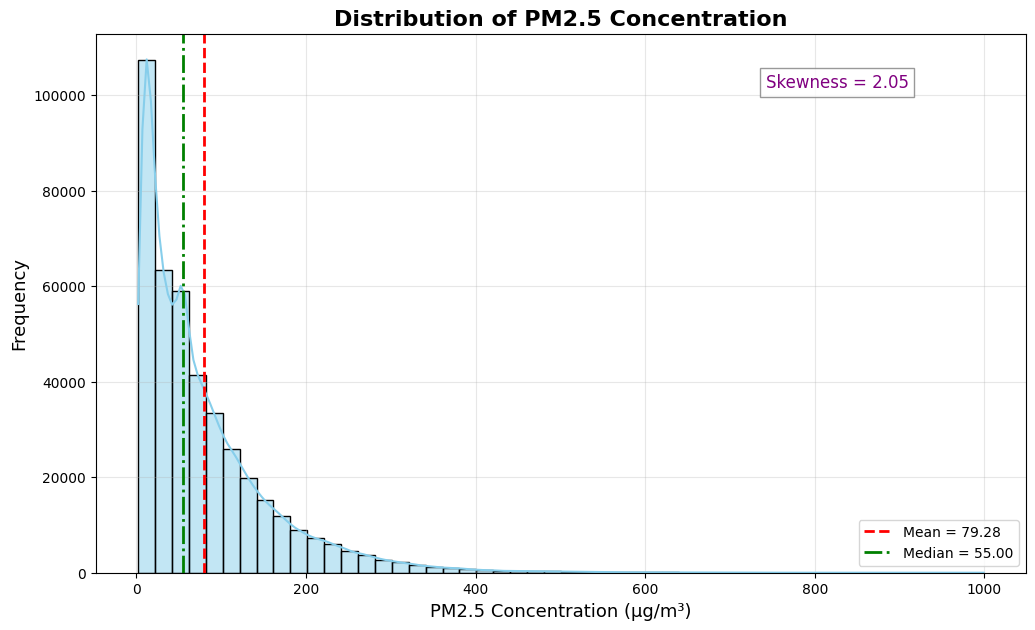

In [25]:
# ==========================================
# Distribution of PM2.5
# ==========================================

from scipy.stats import skew                     # Import skewness function

pm25 = df['PM2.5'].dropna()                      # Extract PM2.5 values, drop missing

mean_val = pm25.mean()                           # Calculate mean
median_val = pm25.median()                       # Calculate median
skewness = round(skew(pm25), 2)                  # Calculate skewness, round to 2 decimals

plt.figure(figsize=(12, 7))                      # Create figure with size 12x7

sns.histplot(                                    # Plot histogram with KDE
    pm25,
    bins=50,                                     # 50 bins
    kde=True,                                    # Add density curve
    color='skyblue',                             # Bar color
    edgecolor='black'                            # Bar edge color
)

plt.axvline(mean_val,                            # Add vertical line for mean
            color='red', linestyle='--', linewidth=2,
            label=f'Mean = {mean_val:.2f}')

plt.axvline(median_val,                          # Add vertical line for median
            color='green', linestyle='-.', linewidth=2,
            label=f'Median = {median_val:.2f}')

plt.title('Distribution of PM2.5 Concentration', # Add plot title
          fontsize=16, fontweight='bold')
plt.xlabel('PM2.5 Concentration (µg/m³)', fontsize=13)  # X-axis label
plt.ylabel('Frequency', fontsize=13)                     # Y-axis label

plt.text(0.72, 0.90, f'Skewness = {skewness}', # Annotate skewness inside plot
         transform=plt.gca().transAxes,
         fontsize=12, color='purple',
         bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))

plt.grid(alpha=0.3)                             # Add light gridlines
plt.legend()                                    # Show legend (mean/median)

plt.show()                                      # Display the plot


### **Interpretation**

### **Analysis of PM2.5 Distribution**

* PM2.5 concentrations are concentrated at lower values, while relatively few observations correspond to extremely high pollution levels, resulting in a pronounced right-skewed distribution.

* The calculated **skewness (2.05)** indicates that the distribution deviates from normality, with extreme pollution episodes contributing to the extended upper tail.

* The difference between the **mean (79.28 µg/m³)** and **median (55.00 µg/m³)** suggests that a small number of high PM2.5 observations increase the average concentration.

* Such behaviour is characteristic of environmental datasets, where pollution levels fluctuate due to meteorological conditions, seasonal influences, and emission events.

### **Overall Observation**

* The exploratory analysis indicates that PM2.5 concentrations exhibit considerable variability and are influenced by occasional extreme pollution events. These characteristics support the selection of tree-based machine learning algorithms, which can effectively model complex, non-linear relationships without requiring the target variable to follow a normal distribution.

### **5.1.1 Descriptive Statistics of PM2.5**

In [26]:
# ==========================================
# Descriptive Statistics of PM2.5
# ==========================================

pm25_summary = pd.DataFrame({
    'Statistic': [
        'Count',                        # Number of non-missing values
        'Mean',                         # Average PM2.5 concentration
        'Median',                       # Middle value
        'Standard Deviation',           # Spread of values
        'Minimum',                      # Lowest observed value
        '25th Percentile (Q1)',         # Lower quartile
        '75th Percentile (Q3)',         # Upper quartile
        'Maximum',                      # Highest observed value
        'Skewness',                     # Asymmetry of distribution
        'Kurtosis'                      # "Peakedness" of distribution
    ],
    'Value': [
        round(pm25.count(), 0),         # Count of values
        round(pm25.mean(), 2),          # Mean
        round(pm25.median(), 2),        # Median
        round(pm25.std(), 2),           # Standard deviation
        round(pm25.min(), 2),           # Minimum
        round(pm25.quantile(0.25), 2),  # Q1
        round(pm25.quantile(0.75), 2),  # Q3
        round(pm25.max(), 2),           # Maximum
        round(pm25.skew(), 2),          # Skewness
        round(pm25.kurt(), 2)           # Kurtosis
    ]
})

display(pm25_summary)                   # Show summary table


,Statistic,Value
0,Count,420768.00
1,Mean,79.28
2,Median,55.00
3,Standard Deviation,80.06
4,Minimum,2.00
5,25th Percentile (Q1),21.00
6,75th Percentile (Q3),109.00
7,Maximum,999.00
8,Skewness,2.05
9,Kurtosis,6.17


### **Interpretation:**

* The **PM2.5** concentration exhibits substantial variability, with values ranging from **2** to **999**, indicating significant fluctuations in air quality across different locations and time periods.

* The **mean (79.28)** is higher than the **median (55.00)**, suggesting that the distribution is **positively skewed**, with a small number of extremely high PM2.5 concentrations increasing the average.

* The interquartile range (**Q1 = 21.00** to **Q3 = 109.00**) indicates that **50% of the observations** fall within this interval, reflecting considerable variation in typical PM2.5 levels.

* The **standard deviation (80.06)** is relatively high, confirming substantial dispersion in PM2.5 concentrations throughout the dataset.

* The **positive skewness (2.05)** indicates that higher PM2.5 values occur less frequently but extend the right tail of the distribution.

* The **kurtosis value (6.17)** suggests a **leptokurtic distribution**, indicating a higher concentration of observations around the centre along with more extreme values than expected under a normal distribution.

### **Overall Observation**

* The descriptive statistics indicate that **PM2.5 concentrations are highly variable and exhibit a non-normal distribution characterised by positive skewness and the presence of extreme values.** These characteristics justify the use of robust preprocessing techniques and machine learning algorithms capable of handling skewed environmental data.

## **5.2 Correlation Analysis**

### **5.2.1 Correlation Matrix**

In [27]:
# ==========================================
# Correlation Matrix
# ==========================================

# Select numerical variables
numerical_cols = [
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'
]

# Calculate correlation matrix
correlation_matrix = df[numerical_cols].corr()   # Pearson correlation by default

# Display rounded values
correlation_matrix.round(2)                      # Round to 2 decimal places for readability


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
PM2.5,1.00,0.88,0.48,0.66,0.77,-0.15,-0.13,0.02,0.11,-0.01,-0.27
PM10,0.88,1.00,0.46,0.65,0.69,-0.11,-0.10,-0.02,0.07,-0.03,-0.18
SO2,0.48,0.46,1.00,0.49,0.52,-0.16,-0.32,0.22,-0.26,-0.04,-0.11
NO2,0.66,0.65,0.49,1.00,0.69,-0.46,-0.27,0.17,-0.03,-0.04,-0.39
CO,0.77,0.69,0.52,0.69,1.00,-0.30,-0.32,0.18,-0.06,-0.01,-0.29
O3,-0.15,-0.11,-0.16,-0.46,-0.30,1.00,0.59,-0.44,0.31,0.02,0.29
TEMP,-0.13,-0.10,-0.32,-0.27,-0.32,0.59,1.00,-0.81,0.82,0.04,0.03
PRES,0.02,-0.02,0.22,0.17,0.18,-0.44,-0.81,1.00,-0.75,-0.06,0.07
DEWP,0.11,0.07,-0.26,-0.03,-0.06,0.31,0.82,-0.75,1.00,0.09,-0.30
RAIN,-0.01,-0.03,-0.04,-0.04,-0.01,0.02,0.04,-0.06,0.09,1.00,0.02


### **Interpretation:**

* The correlation matrix indicates that **PM2.5** has **strong positive correlations** with **PM10 (0.88)** and **CO (0.77)**, suggesting that these pollutants tend to increase together and may originate from similar emission sources.

* A **moderately positive correlation** is observed between **PM2.5** and **NO2 (0.66)**, while **SO2 (0.48)** exhibits a weaker positive relationship with PM2.5.

* **Meteorological variables** generally show **weak correlations** with PM2.5. **Temperature (TEMP)** and **wind speed (WSPM)** have weak negative correlations, indicating that higher temperatures and stronger winds are associated with slightly lower PM2.5 concentrations.

* A **strong positive correlation** exists between **TEMP** and **DEWP (0.82)**, whereas **TEMP** and **PRES (-0.81)** exhibit a strong negative correlation, reflecting the natural relationships among meteorological variables.

* **O3** demonstrates a moderate positive correlation with **TEMP (0.59)** and a moderate negative correlation with **NO2 (-0.46)**, indicating that ozone concentrations vary differently from several primary pollutants.

### **Overall Observation**

* The correlation analysis reveals that **PM2.5 is more strongly associated with other air pollutants than with meteorological variables.** While several variables exhibit moderate to strong relationships, no pair demonstrates perfect correlation, indicating that the selected features provide complementary information for predictive modelling without severe multicollinearity.

### **5.2.2 Correlation Heatmap**

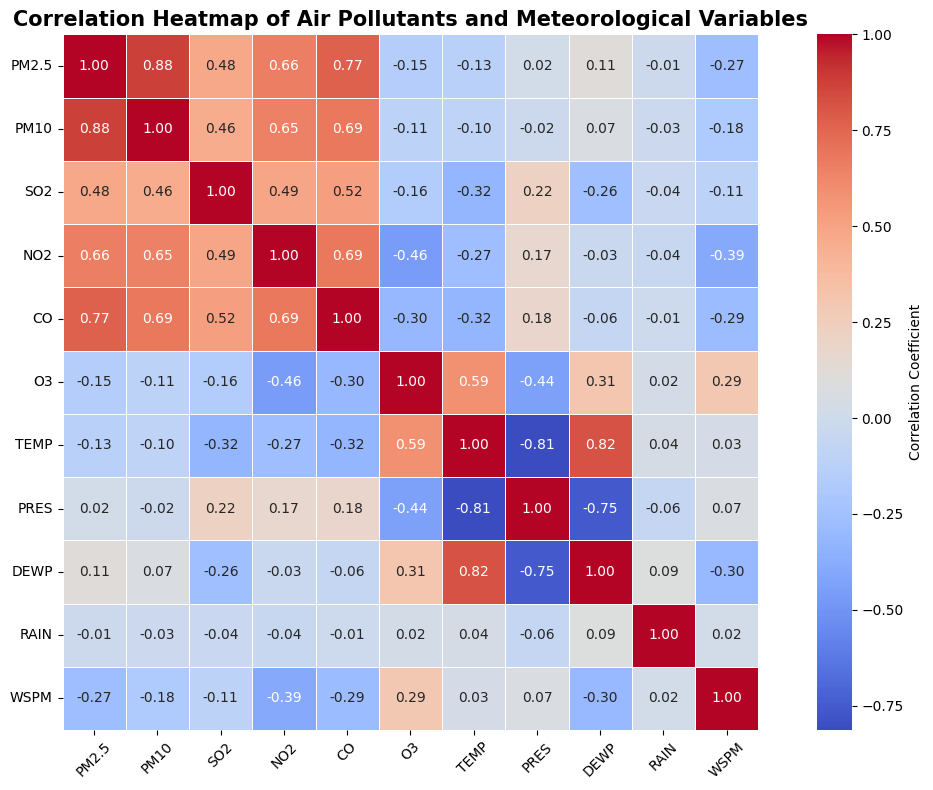

In [28]:
# ==========================================
# 5.2.2 Correlation Heatmap
# ==========================================

plt.figure(figsize=(12, 8))                  # Set figure size

sns.heatmap(                                 # Create heatmap
    correlation_matrix,                      # Use correlation matrix
    annot=True,                              # Show correlation values
    cmap='coolwarm',                         # Color scheme (blue-red)
    fmt='.2f',                               # Format numbers to 2 decimals
    linewidths=0.5,                          # Thin lines between cells
    square=True,                             # Keep cells square-shaped
    cbar_kws={'label': 'Correlation Coefficient'}  # Label for color bar
)

plt.title(                                   # Add title
    'Correlation Heatmap of Air Pollutants and Meteorological Variables',
    fontsize=15,
    fontweight='bold'
)

plt.xticks(rotation=45)                      # Rotate x-axis labels for readability
plt.yticks(rotation=0)                       # Keep y-axis labels horizontal

plt.tight_layout()                           # Adjust layout to fit labels
plt.show()                                   # Display the heatmap


### **Interpretation:**

* The heatmap provides a visual representation of the relationships among air pollutants and meteorological variables, where warmer colours indicate positive correlations and cooler colours indicate negative correlations.

* **PM2.5** exhibits strong positive correlations with **PM10** and **CO**, indicating that these pollutants tend to increase simultaneously and may share common emission sources.

* Moderate positive correlations are observed between **PM2.5** and **NO2**, while weaker positive relationships exist with **SO2**, suggesting varying degrees of association among air pollutants.

* Meteorological variables display comparatively weaker relationships with **PM2.5**. Higher **temperature (TEMP)** and **wind speed (WSPM)** are associated with slightly lower PM2.5 concentrations, whereas **pressure (PRES)** shows little direct relationship with PM2.5.

* Strong relationships are evident among the meteorological variables themselves, particularly between **TEMP** and **DEWP** (positive correlation) and between **TEMP** and **PRES** (negative correlation), reflecting their natural atmospheric interactions.

### **Overall Observation**

* The heatmap indicates that **PM2.5 exhibits stronger correlations with other air pollutants than with meteorological variables.** The presence of moderate and strong correlations highlights meaningful relationships among the variables while indicating that the dataset retains sufficient feature diversity for subsequent machine learning modelling.

## **5.3 Monthly Variation of PM2.5**

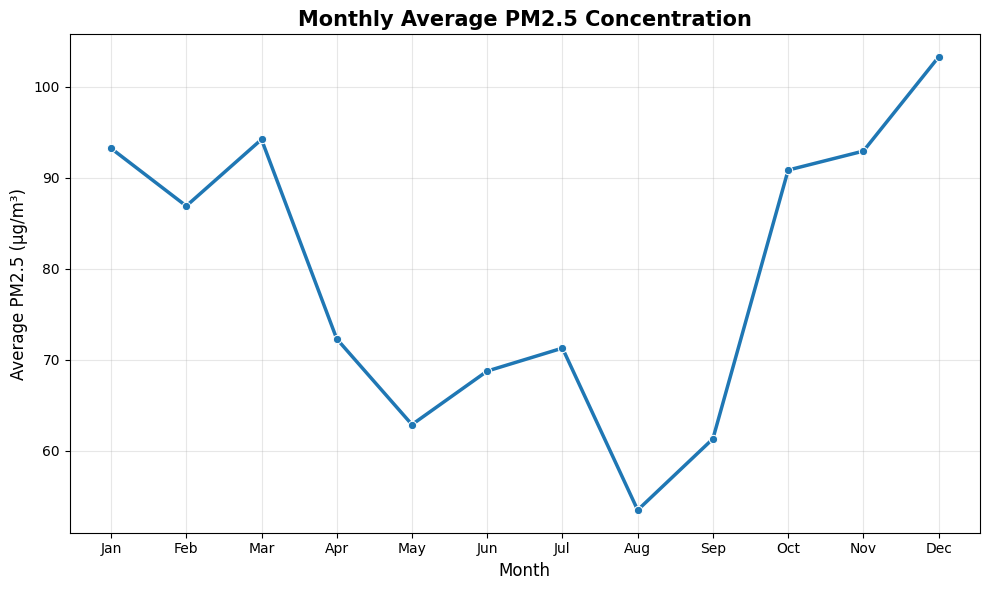

In [29]:
# Calculate monthly average PM2.5
monthly_pm25 = (                               # Create new DataFrame
    df.groupby('month')['PM2.5']               # Group data by month
      .mean()                                  # Calculate mean PM2.5 for each month
      .reset_index()                           # Reset index so 'month' becomes a column
)

monthly_pm25                                  # Display monthly averages


plt.figure(figsize=(10,6))                     # Set figure size

sns.lineplot(                                  # Create line plot
    data=monthly_pm25,                         # Use monthly averages
    x='month',                                 # Month on x-axis
    y='PM2.5',                                 # Average PM2.5 on y-axis
    marker='o',                                # Add markers at each point
    linewidth=2.5                              # Thicker line for clarity
)

plt.title(                                     # Add chart title
    'Monthly Average PM2.5 Concentration',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Month', fontsize=12)               # Label x-axis
plt.ylabel('Average PM2.5 (µg/m³)', fontsize=12) # Label y-axis

# Show month names instead of numbers
plt.xticks(                                    # Customize x-axis ticks
    ticks=range(1,13),                         # Months 1–12
    labels=['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec'] # Month names
)

plt.grid(alpha=0.3)                            # Add light gridlines
plt.tight_layout()                             # Adjust layout to fit labels
plt.show()                                     # Display the plot


### **Interpretation:**

* The monthly average **PM2.5** concentration exhibits a clear seasonal pattern, with pollution levels varying considerably throughout the year.

* Higher PM2.5 concentrations are observed during the **winter months (October-March)**, while lower concentrations occur during the **summer months (May-September)**.

* The average PM2.5 concentration reaches its **highest level in December**, whereas the **lowest concentration is recorded in August**, indicating substantial seasonal variation in air quality.

* Following a decline from March to August, PM2.5 concentrations increase steadily from September onwards, suggesting a recurring annual trend in pollution levels.

### **Overall Observation**

* The monthly trend indicates that **PM2.5 concentrations are influenced by seasonal factors.** This pattern highlights the importance of including **month** as a predictor variable in the machine learning models to capture seasonal variations in air quality.

## **5.4 Station-wise PM2.5 Analysis**

### **5.4.1 Average PM2.5 by Station**

In [30]:
# ==========================================
# Average PM2.5 Concentration by Station
# ==========================================

station_pm25 = (                              # Create new DataFrame
    df.groupby('station')['PM2.5']            # Group data by station
      .mean()                                 # Calculate mean PM2.5 for each station
      .sort_values(ascending=False)           # Sort stations by average PM2.5 (highest first)
      .reset_index()                          # Reset index so 'station' becomes a column
)

station_pm25                                 # Display the result


,station,PM2.5
0,Dongsi,85.527068
1,Wanshouxigong,84.428174
2,Nongzhanguan,84.304073
3,Gucheng,83.320534
4,Wanliu,83.065591
5,Guanyuan,82.442642
6,Aotizhongxin,82.040934
7,Tiantan,81.640423
8,Shunyi,78.853887
9,Changping,70.744359


## **Interpretation:**

* The average PM2.5 concentration varies across the monitoring stations, indicating noticeable spatial differences in air quality within the study area.

* **Dongsi** records the highest average PM2.5 concentration (**85.53 µg/m³**), followed by **Wanshouxigong** and **Nongzhanguan**, suggesting relatively higher pollution levels at these locations.

* In contrast, **Dingling** records the lowest average PM2.5 concentration (**65.75 µg/m³**), indicating comparatively better air quality than the other monitoring stations.

* Although the stations exhibit different pollution levels, the variation in average PM2.5 concentrations is moderate, suggesting that air pollution is present across all monitoring locations.

### **Overall Observation**

* The station-wise analysis demonstrates that **PM2.5 concentrations are spatially distributed across the monitoring network**, indicating that geographical location is associated with variations in air quality. As **station** is included as a predictor variable, these spatial differences may contribute to improving the prediction of PM2.5 concentrations.

### **5.4.2 Bar Chart**

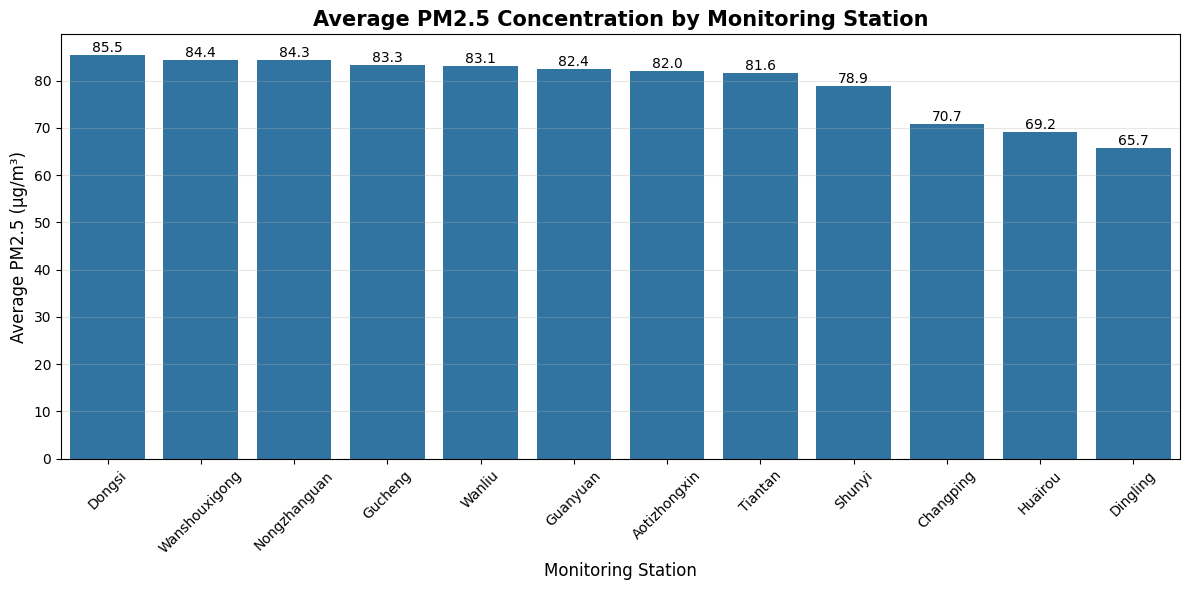

In [31]:
# ==========================================
# Bar Chart of Average PM2.5 by Station
# ==========================================

plt.figure(figsize=(12,6))                     # Set figure size

ax = sns.barplot(                              # Create bar chart
    data=station_pm25,                         # Use station-level averages
    x='station',                               # Stations on x-axis
    y='PM2.5'                                  # Average PM2.5 on y-axis
)

# Add value labels on top of bars
for container in ax.containers:                # Loop through bar containers
    ax.bar_label(container, fmt='%.1f', fontsize=10)  # Show values with 1 decimal

plt.title(                                     # Add chart title
    'Average PM2.5 Concentration by Monitoring Station',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Monitoring Station', fontsize=12)  # Label x-axis
plt.ylabel('Average PM2.5 (µg/m³)', fontsize=12) # Label y-axis

plt.xticks(rotation=45)                        # Rotate station names for readability

plt.grid(axis='y', alpha=0.3)                  # Add horizontal gridlines

plt.tight_layout()                             # Adjust layout to fit labels

plt.show()                                     # Display the plot


### **Interpretation:**

* The bar chart illustrates the average **PM2.5** concentration across the twelve monitoring stations, highlighting the spatial variation in air quality.

* **Dongsi** records the highest average PM2.5 concentration (**85.53 µg/m³**), followed by **Wanshouxigong** and **Nongzhanguan**, indicating relatively higher pollution levels at these monitoring locations.

* In contrast, **Dingling** records the lowest average PM2.5 concentration (**65.75 µg/m³**), followed by **Huairou** and **Changping**, suggesting comparatively better air quality at these stations.

* Although differences exist among the monitoring stations, the average PM2.5 concentrations remain relatively high across all locations, indicating that particulate pollution is a widespread concern within the study area.

### **Overall Observation**

* The bar chart highlights noticeable spatial variation in PM2.5 concentrations across the monitoring stations. These differences suggest that geographical location contributes to variations in air quality, supporting the inclusion of the **station** variable as a predictor in the machine learning models.

### **5.4.3 Highest and Lowest Pollution Stations**

In [32]:
# ==========================================
# Highest and Lowest PM2.5 Stations
# ==========================================

highest_station = station_pm25.iloc[0]          # Select first row (highest average PM2.5)
lowest_station = station_pm25.iloc[-1]          # Select last row (lowest average PM2.5)

print("Highest Average PM2.5 Station")          # Label output
print(f"{highest_station['station']} : {highest_station['PM2.5']:.2f} µg/m³")
# Print station name and value (formatted to 2 decimals)

print("\nLowest Average PM2.5 Station")         # Label output
print(f"{lowest_station['station']} : {lowest_station['PM2.5']:.2f} µg/m³")
# Print station name and value (formatted to 2 decimals)


Highest Average PM2.5 Station
Dongsi : 85.53 µg/m³

Lowest Average PM2.5 Station
Dingling : 65.75 µg/m³


### **Interpretation:**

* Among the twelve monitoring stations, **Dongsi** recorded the **highest average PM2.5 concentration** (**85.53 µg/m³**), indicating comparatively poorer air quality.

* **Dingling** recorded the **lowest average PM2.5 concentration** (**65.75 µg/m³**), suggesting comparatively better air quality among the monitored locations.

* The difference between the highest and lowest average PM2.5 concentrations indicates noticeable spatial variation in particulate pollution across the monitoring network.

### **Overall Observation**

* The results demonstrate that PM2.5 concentrations are not uniformly distributed across the monitoring stations. This spatial variation suggests that air quality differs across locations and highlights the importance of considering geographical differences when analysing environmental pollution.

## **5.5 Relationship Between Meteorological Variables and PM2.5**

### **5.5.1 Scatter Plots**

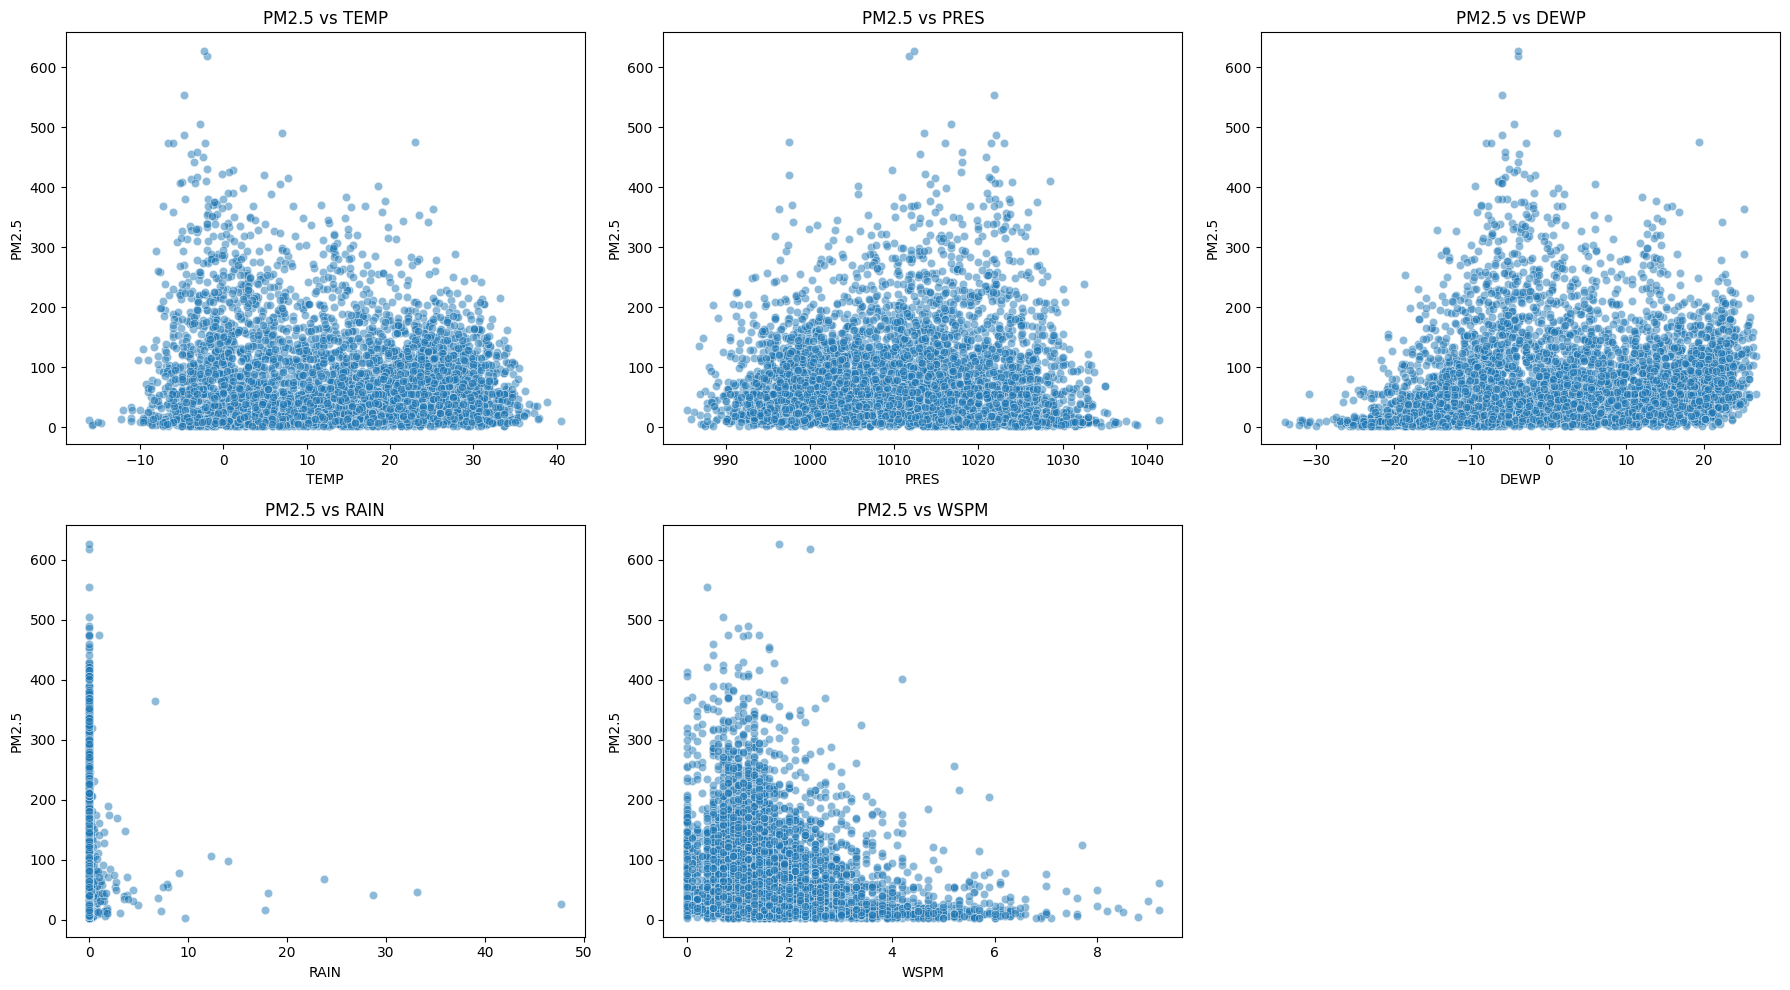

In [33]:
# ==========================================
# Relationship Between Meteorological Variables and PM2.5
# ==========================================

meteorological_vars = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']   # List of weather variables

plt.figure(figsize=(18,10))                                      # Create figure with size 18x10

for i, var in enumerate(meteorological_vars, 1):                 # Loop through variables with index
    plt.subplot(2,3,i)                                           # Create subplot grid (2 rows, 3 cols)

    sns.scatterplot(                                             # Scatter plot for each variable
        data=df.sample(5000, random_state=42),                   # Use random sample of 5000 rows for speed
        x=var,                                                   # Meteorological variable on x-axis
        y='PM2.5',                                               # PM2.5 concentration on y-axis
        alpha=0.5                                                # Semi-transparent points
    )

    plt.title(f'PM2.5 vs {var}')                                 # Add subplot title
    plt.xlabel(var)                                              # Label x-axis
    plt.ylabel('PM2.5')                                          # Label y-axis

plt.tight_layout()                                               # Adjust layout to avoid overlap
plt.show()                                                       # Display all subplots


### **Interpretation:**

* The scatter plots illustrate the relationships between **PM2.5** concentrations and the selected meteorological variables (**TEMP, PRES, DEWP, RAIN, and WSPM**). The wide dispersion of data points indicates that these relationships are not strictly linear.

* **Temperature (TEMP)** exhibits a weak negative relationship with PM2.5, suggesting that higher temperatures are generally associated with slightly lower particulate matter concentrations.

* **Pressure (PRES)** and **dew point (DEWP)** show weak associations with PM2.5, indicating that these variables alone do not strongly explain variations in particulate matter levels.

* **Rainfall (RAIN)** displays no clear relationship with PM2.5, with most observations concentrated at low rainfall values and only a few observations recorded during periods of higher rainfall.

* **Wind speed (WSPM)** exhibits a weak negative relationship with PM2.5, where higher wind speeds are generally associated with lower PM2.5 concentrations, likely due to the dispersion of airborne pollutants.

### **Overall Observation**

* The scatter plots suggest that individual meteorological variables have relatively weak relationships with PM2.5 concentrations. This indicates that PM2.5 levels are likely influenced by the combined effects of multiple meteorological and air pollutant variables rather than by any single environmental factor.

### **5.5.2 Correlation of Meteorological Variables with PM2.5**

In [34]:
# ==========================================
# Correlation of Meteorological Variables with PM2.5
# ==========================================

pm25_corr = (                                # Create correlation series
    df[meteorological_vars + ['PM2.5']]      # Select meteorological variables + PM2.5
      .corr()['PM2.5']                       # Compute correlation matrix, extract PM2.5 column
      .drop('PM2.5')                         # Drop self-correlation (always 1.0)
      .sort_values(ascending=False)          # Sort correlations from strongest positive to weakest
)

pm25_corr                                   # Display correlations


,PM2.5
DEWP,0.112726
PRES,0.019235
RAIN,-0.014315
TEMP,-0.130825
WSPM,-0.269476


### **Interpretation:**

* The correlation analysis indicates that the meteorological variables exhibit relatively weak relationships with **PM2.5** concentrations.

* **DEWP** shows the strongest positive correlation (**0.11**) with PM2.5, although the relationship remains weak.

* **Temperature (TEMP)** and **wind speed (WSPM)** exhibit negative correlations with PM2.5, with **WSPM (-0.27)** showing the strongest negative association among the selected meteorological variables. This suggests that higher wind speeds are generally associated with lower PM2.5 concentrations.

* **Pressure (PRES)** and **rainfall (RAIN)** display negligible correlations with PM2.5, indicating limited linear relationships with particulate matter concentrations.

### **Overall Observation**

* The results suggest that no single meteorological variable has a strong linear relationship with **PM2.5**. Instead, PM2.5 concentrations are likely influenced by the combined effects of multiple meteorological conditions and other environmental factors.

# **6. Model Development**

## **6.1 Feature Selection**

* The target variable for prediction was **PM2.5**. Predictor variables were selected by excluding the target variable (**PM2.5**), the **No** column, which serves as a record identifier, and the engineered **datetime** column. The categorical variables (**station** and **wd**) were retained and transformed into numerical features using one-hot encoding to enable their use in machine learning models.

In [35]:
# Target variable
y = df['PM2.5']                               # Define target (dependent variable)

# Predictor variables
X = df.drop(columns=['PM2.5', 'datetime', 'No'])   # Define predictors (independent variables)
                                                    # Drop target, datetime and No (not useful for ML)

print("Predictor Variables Shape:", X.shape)  # Show dimensions of X (rows × features)
print("Target Variable Shape:", y.shape)      # Show dimensions of y (rows,)

display(X.head())                             # Preview first 5 rows of predictors
display(y.head())                             # Preview first 5 values of target

Predictor Variables Shape: (420768, 16)
Target Variable Shape: (420768,)


,year,month,day,hour,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013,3,1,0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2013,3,1,1,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,2013,3,1,2,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,2013,3,1,3,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,2013,3,1,4,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


,PM2.5
0,4.0
1,8.0
2,7.0
3,6.0
4,3.0


### **Interpretation:**

* The dataset was successfully divided into **predictor variables (X)** and the **target variable (y)**, with **PM2.5** selected as the dependent variable for prediction.

* The predictor dataset contains **420,768 observations** and **16 predictor variables**, while the target variable contains **420,768 corresponding observations**, confirming that both datasets are correctly aligned for machine learning.

* The predictor variables include **temporal, air pollutant, meteorological, and categorical features**, providing a comprehensive set of information for predicting PM2.5 concentrations.

* The preview of the predictor variables and target variable confirms that the data has been correctly separated, with **PM2.5** excluded from the predictor dataset.

### **Overall Observation**

* The successful separation of predictor variables and the target variable establishes the required input structure for supervised machine learning. The dataset is now prepared for feature encoding, train-test splitting, and model development.

## **6.2 Encode Categorical Variables**

In [36]:
# One-Hot Encoding of categorical variables
X = pd.get_dummies(                           # Apply one-hot encoding
    X,                                        # DataFrame of predictors
    columns=['station', 'wd'],                # Encode categorical columns: station, wind direction
    drop_first=True                           # Drop first category to avoid dummy variable trap
)

print("Shape after encoding:", X.shape)       # Show new shape after encoding

display(X.head())                             # Preview first 5 rows of encoded predictors


Shape after encoding: (420768, 40)


,year,month,day,hour,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,station_Changping,station_Dingling,station_Dongsi,station_Guanyuan,station_Gucheng,station_Huairou,station_Nongzhanguan,station_Shunyi,station_Tiantan,station_Wanliu,station_Wanshouxigong,wd_ENE,wd_ESE,wd_N,wd_NE,wd_NNE,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW
0,2013,3,1,0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,4.4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,2013,3,1,1,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,4.7,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,2013,3,1,2,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,5.6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,2013,3,1,3,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,3.1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,2013,3,1,4,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,2.0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


### **Interpretation:**

* The categorical variables **station** and **wd** were successfully transformed into numerical features using **one-hot encoding**, making them suitable for machine learning algorithms.

* Following the encoding process, the number of predictor variables increased from **16** to **40**, reflecting the creation of binary indicator variables for each category within the **station** and **wd** features.

* The encoded variables are represented as **True/False** values, where **True** indicates the presence of a particular category and **False** indicates its absence for a given observation.

* The preview of the encoded dataset confirms that the original categorical variables have been replaced with their corresponding binary features while all numerical variables remain unchanged.

### **Overall Observation**

* One-hot encoding successfully converted the categorical variables into a numerical format without introducing any ordinal relationships between categories. As a result, the dataset is fully prepared for train-test splitting and subsequent machine learning model development.

## **6.3 Train-Test Split**

In [37]:
from sklearn.model_selection import train_test_split   # Import function to split dataset

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,                                                 # Predictor variables
    y,                                                 # Target variable (PM2.5)
    test_size=0.20,                                    # 20% data for testing, 80% for training
    random_state=42                                    # Fixed seed for reproducibility
)

print("Training Features:", X_train.shape)             # Show shape of training predictors
print("Testing Features :", X_test.shape)              # Show shape of testing predictors

print("Training Target  :", y_train.shape)             # Show shape of training target
print("Testing Target   :", y_test.shape)              # Show shape of testing target


Training Features: (336614, 40)
Testing Features : (84154, 40)
Training Target  : (336614,)
Testing Target   : (84154,)


### **Interpretation:**

* The dataset was successfully divided into **training** and **testing** sets using an **80:20 split**, with **80%** of the observations allocated for model training and **20%** reserved for model evaluation.

* The training dataset contains **336,614 observations** with **40 predictor variables**, while the testing dataset contains **84,154 observations** with the same set of predictor variables.

* The target variable was split accordingly, ensuring that each predictor dataset has a corresponding set of PM2.5 values for supervised learning.

* A fixed **random_state** of **42** was used during the split to ensure that the results are reproducible across different executions.

### **Overall Observation**

* The successful train-test split ensures that the machine learning models are trained on one subset of the data and evaluated on an independent subset. This approach helps assess the models' ability to generalize to unseen data and reduces the risk of overfitting.

## **6.4 Model Building**

## **6.4.1 Linear Regression**

*  **Linear Regression** was selected as the baseline model for predicting **PM2.5** concentrations. The model assumes a linear relationship between the predictor variables and the target variable and provides a simple yet effective benchmark for evaluating the performance of more advanced machine learning models. Model performance was assessed using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)**.

In [38]:
from sklearn.linear_model import LinearRegression                 # Import Linear Regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np                                                # Import NumPy for math functions

# Train the model
lr_model = LinearRegression()                                     # Initialize Linear Regression
lr_model.fit(X_train, y_train)                                    # Fit model on training data

# Predictions
y_pred_lr = lr_model.predict(X_test)                              # Predict PM2.5 on test set

# Evaluation metrics
lr_mae = mean_absolute_error(y_test, y_pred_lr)                   # Mean Absolute Error
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))          # Root Mean Squared Error
lr_r2 = r2_score(y_test, y_pred_lr)                               # R² score (variance explained)

print("Linear Regression Performance")                            # Print header
print(f"MAE  : {lr_mae:.2f}")                                     # Print MAE (2 decimals)
print(f"RMSE : {lr_rmse:.2f}")                                    # Print RMSE (2 decimals)
print(f"R²   : {lr_r2:.4f}")                                      # Print R² (4 decimals)


Linear Regression Performance
MAE  : 20.52
RMSE : 31.79
R²   : 0.8422


### **Interpretation:**

* The Linear Regression model achieved a **Mean Absolute Error (MAE)** of **20.52 µg/m³**, indicating that the predicted PM2.5 concentrations differed from the actual values by an average of approximately **20.52 µg/m³**.

* The **Root Mean Squared Error (RMSE)** of **31.79 µg/m³** is higher than the MAE, suggesting the presence of some larger prediction errors, as RMSE assigns greater weight to larger deviations.

* The model achieved an **R² score of 0.8422**, indicating that approximately **84.22%** of the variability in PM2.5 concentrations was explained by the predictor variables.

### **Overall Observation**

* The Linear Regression model demonstrated strong predictive performance and provided a reliable baseline for comparison with the more advanced machine learning models evaluated in this study.

## **6.4.2 Decision Tree Regressor**

*  **Decision Tree Regressor** was developed to capture the non-linear relationships between the predictor variables and **PM2.5** concentrations. Unlike Linear Regression, Decision Trees recursively partition the dataset into smaller subsets based on feature values, enabling the model to learn complex patterns and interactions without assuming a linear relationship. The model performance was evaluated using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)**.

In [39]:
from sklearn.tree import DecisionTreeRegressor          # Import Decision Tree Regressor

# Train Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)       # Initialize model with fixed seed
dt_model.fit(X_train, y_train)                          # Fit model on training data

# Predictions
y_pred_dt = dt_model.predict(X_test)                    # Predict PM2.5 on test set

# Evaluation metrics
dt_mae = mean_absolute_error(y_test, y_pred_dt)         # Mean Absolute Error
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))# Root Mean Squared Error
dt_r2 = r2_score(y_test, y_pred_dt)                     # R² score (variance explained)

print("Decision Tree Performance")                      # Print header
print(f"MAE  : {dt_mae:.2f}")                           # Print MAE (2 decimals)
print(f"RMSE : {dt_rmse:.2f}")                          # Print RMSE (2 decimals)
print(f"R²   : {dt_r2:.4f}")                            # Print R² (4 decimals)


Decision Tree Performance
MAE  : 13.81
RMSE : 25.72
R²   : 0.8967


### **Interpretation:**

* The Decision Tree Regressor achieved a **Mean Absolute Error (MAE)** of **13.81 µg/m³**, indicating that the predicted PM2.5 concentrations differed from the actual values by an average of approximately **13.81 µg/m³**.

* The model produced a **Root Mean Squared Error (RMSE)** of **25.72 µg/m³**, suggesting that the overall prediction error was lower than that of the Linear Regression model.

* The **R² score** of **0.8967** indicates that approximately **89.67%** of the variability in PM2.5 concentrations was explained by the predictor variables.

### **Overall Observation**

* Compared with the Linear Regression model, the Decision Tree Regressor demonstrated improved predictive performance, with lower prediction errors (MAE and RMSE) and a higher R² score. These results indicate that the Decision Tree was more effective at capturing the complex, non-linear relationships between the predictor variables and PM2.5 concentrations.

## **6.4.3 Random Forest Regressor**

* **Random Forest Regressor** was developed as an ensemble learning model that combines multiple decision trees to improve prediction accuracy and reduce overfitting. Each tree is trained on a random subset of the training data and predictor variables, and the final prediction is obtained by averaging the predictions from all trees in the ensemble. The model performance was evaluated using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)**..

In [40]:
from sklearn.ensemble import RandomForestRegressor          # Import Random Forest Regressor

# Train Random Forest model
rf_model = RandomForestRegressor(                           # Initialize model
    n_estimators=100,                                       # Number of trees in the forest
    random_state=42,                                        # Fixed seed for reproducibility
    n_jobs=-1                                               # Use all CPU cores for faster training
)

rf_model.fit(X_train, y_train)                              # Fit model on training data

# Predictions
y_pred_rf = rf_model.predict(X_test)                        # Predict PM2.5 on test set

# Evaluation metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)             # Mean Absolute Error
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))    # Root Mean Squared Error
rf_r2 = r2_score(y_test, y_pred_rf)                         # R² score (variance explained)

print("Random Forest Performance")                          # Print header
print(f"MAE  : {rf_mae:.2f}")                               # Print MAE (2 decimals)
print(f"RMSE : {rf_rmse:.2f}")                              # Print RMSE (2 decimals)
print(f"R²   : {rf_r2:.4f}")                                # Print R² (4 decimals)


Random Forest Performance
MAE  : 10.13
RMSE : 17.83
R²   : 0.9503


### **Interpretation:**

* The Random Forest Regressor achieved a **Mean Absolute Error (MAE)** of **10.13 µg/m³**, indicating that the predicted PM2.5 concentrations differed from the actual values by an average of approximately **10.13 µg/m³**.

* The model produced a **Root Mean Squared Error (RMSE)** of **17.83 µg/m³**, demonstrating a substantial reduction in prediction error compared with both the Linear Regression and Decision Tree models.

* The **R² score** of **0.9503** indicates that approximately **95.03%** of the variability in PM2.5 concentrations was explained by the predictor variables.

### **Overall Observation**

* Among the models evaluated so far, the Random Forest Regressor demonstrated the strongest predictive performance, achieving the lowest MAE and RMSE values and the highest R² score. These results indicate that the ensemble learning approach was highly effective in capturing the complex relationships between the predictor variables and PM2.5 concentrations while providing better generalization than a single Decision Tree.

## **6.4.4 XGBoost Regression**

* **XGBoost (Extreme Gradient Boosting)** is an advanced ensemble learning algorithm based on gradient boosting. Unlike Random Forest, which builds decision trees independently, XGBoost constructs trees sequentially, with each new tree learning to correct the prediction errors of the previous trees. This iterative learning process enables the model to capture complex nonlinear relationships while improving predictive accuracy. The model performance was evaluated using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)**.

In [41]:
# ============================================================
# 6.4.4 XGBoost Regressor
# ============================================================

from xgboost import XGBRegressor                           # Import XGBoost Regressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np                                         # NumPy for math functions

# ------------------------------------------------------------
# Train XGBoost Model
# ------------------------------------------------------------
xgb_model = XGBRegressor(                                  # Initialize model
    n_estimators=100,                                      # Number of boosting rounds (trees)
    learning_rate=0.1,                                     # Step size shrinkage
    max_depth=6,                                           # Maximum depth of each tree
    random_state=42,                                       # Fixed seed for reproducibility
    n_jobs=-1                                              # Use all CPU cores for speed
)

xgb_model.fit(X_train, y_train)                            # Fit model on training data

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------
y_pred_xgb = xgb_model.predict(X_test)                     # Predict PM2.5 on test set

# ------------------------------------------------------------
# Evaluation Metrics
# ------------------------------------------------------------
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)          # Mean Absolute Error
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb)) # Root Mean Squared Error
xgb_r2 = r2_score(y_test, y_pred_xgb)                      # R² score (variance explained)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------
print("="*60)
print("XGBOOST REGRESSOR PERFORMANCE")
print("="*60)

print(f"MAE  : {xgb_mae:.2f}")                             # Print MAE (2 decimals)
print(f"RMSE : {xgb_rmse:.2f}")                            # Print RMSE (2 decimals)
print(f"R²   : {xgb_r2:.4f}")                              # Print R² (4 decimals)


XGBOOST REGRESSOR PERFORMANCE
MAE  : 12.77
RMSE : 20.72
R²   : 0.9330


### **Interpretation:**

* The XGBoost Regressor achieved a **Mean Absolute Error (MAE)** of **12.77 µg/m³**, indicating that the predicted PM2.5 concentrations differed from the actual values by an average of approximately **12.77 µg/m³**.

* The model produced a **Root Mean Squared Error (RMSE)** of **20.72 µg/m³**, demonstrating good predictive accuracy with relatively low overall prediction error.

* The **R² score** of **0.9330** indicates that approximately **93.30%** of the variability in PM2.5 concentrations was explained by the predictor variables.

### **Overall Observation**

* The XGBoost Regressor demonstrated strong predictive performance, substantially outperforming both the Linear Regression and Decision Tree models. However, compared with the Random Forest Regressor, XGBoost produced slightly higher prediction errors and a lower R² score on this dataset. These findings suggest that, under the selected model parameters, Random Forest provided the best predictive performance for PM2.5 concentration prediction.

## **6.4.5 Gradient Boosting Regressor**

* **Gradient Boosting Regressor** was implemented as an ensemble learning algorithm that sequentially builds decision trees, with each new tree correcting the prediction errors of the previous trees. By combining multiple weak learners into a strong predictive model, Gradient Boosting is capable of capturing complex nonlinear relationships in the data while improving predictive accuracy. The model performance was evaluated using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)**.

In [42]:
from sklearn.ensemble import GradientBoostingRegressor       # Import Gradient Boosting Regressor

# Train Gradient Boosting model
gb_model = GradientBoostingRegressor(                        # Initialize model
    n_estimators=100,                                        # Number of boosting stages (trees)
    random_state=42                                          # Fixed seed for reproducibility
)

gb_model.fit(X_train, y_train)                               # Fit model on training data

# Predictions
y_pred_gb = gb_model.predict(X_test)                         # Predict PM2.5 on test set

# Evaluation metrics
gb_mae = mean_absolute_error(y_test, y_pred_gb)              # Mean Absolute Error
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))     # Root Mean Squared Error
gb_r2 = r2_score(y_test, y_pred_gb)                          # R² score (variance explained)

print("Gradient Boosting Performance")                       # Print header
print(f"MAE  : {gb_mae:.2f}")                                # Print MAE (2 decimals)
print(f"RMSE : {gb_rmse:.2f}")                               # Print RMSE (2 decimals)
print(f"R²   : {gb_r2:.4f}")                                 # Print R² (4 decimals)


Gradient Boosting Performance
MAE  : 15.89
RMSE : 25.40
R²   : 0.8993


### **Interpretation:**

* The Gradient Boosting Regressor achieved a **Mean Absolute Error (MAE)** of **15.89 µg/m³**, indicating that the predicted PM2.5 concentrations differed from the actual values by an average of approximately **15.89 µg/m³**.

* The model produced a **Root Mean Squared Error (RMSE)** of **25.40 µg/m³**, indicating a moderate level of prediction error across the test dataset.

* The **R² score** of **0.8993** indicates that approximately **89.93%** of the variability in PM2.5 concentrations was explained by the predictor variables.

### **Overall Observation**

* The Gradient Boosting Regressor demonstrated good predictive performance, outperforming the Linear Regression model and achieving results comparable to the Decision Tree Regressor. However, it produced higher prediction errors and a lower R² score than both the Random Forest and XGBoost models. These findings indicate that, with the selected model parameters, Gradient Boosting was effective for PM2.5 prediction but was not the best-performing model in this study.

## **6.5 Random Forest Cross Validation**

* Cross-validation was performed to assess the generalization ability and robustness of the best-performing machine learning model. A 5-fold cross-validation strategy was applied to the Random Forest model using the coefficient of determination (R²) as the evaluation metric. This approach provides a more reliable estimate of model performance by repeatedly training and testing the model on different subsets of the dataset.

In [43]:
from sklearn.model_selection import cross_val_score          # Import cross-validation function

# ============================================================
# 6.5 Cross-Validation
# ============================================================

# Select a representative random sample of the training data
X_cv = X_train.sample(n=50000, random_state=42)              # Sample 50k rows for efficiency
y_cv = y_train.loc[X_cv.index]                               # Match target values to sampled rows

# Perform 5-fold Cross-Validation
cv_scores = cross_val_score(                                 # Run cross-validation
    rf_model,                                                # Use Random Forest model
    X_cv,                                                    # Predictors
    y_cv,                                                    # Target
    cv=5,                                                    # 5 folds
    scoring='r2',                                            # Evaluate with R² score
    n_jobs=-1                                                # Use all CPU cores for speed
)

# Display Results
print("=" * 60)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 60)

for i, score in enumerate(cv_scores, start=1):               # Loop through folds
    print(f"Fold {i}: R² = {score:.4f}")                     # Print R² for each fold

print(f"\nAverage R² : {cv_scores.mean():.4f}")              # Print mean R²
print(f"Std Dev    : {cv_scores.std():.4f}")                 # Print standard deviation


5-FOLD CROSS-VALIDATION RESULTS
Fold 1: R² = 0.9169
Fold 2: R² = 0.9218
Fold 3: R² = 0.9242
Fold 4: R² = 0.9277
Fold 5: R² = 0.9184

Average R² : 0.9218
Std Dev    : 0.0039


### **Note:** To reduce computational time while maintaining a reliable estimate of model performance, **5-fold cross-validation** was performed on a representative random sample (**50,000 observations**) of the training dataset.

### **Interpretation:**

* The **5-fold cross-validation** results indicate that the Random Forest Regressor consistently achieved high predictive performance across all validation folds.

* The **R² scores** ranged from **0.9169** to **0.9277**, demonstrating stable model performance regardless of the subset of data used for validation.

* The **average R² score** of **0.9218** indicates that the model explained approximately **92.18%** of the variability in PM2.5 concentrations across the validation folds.

* The **standard deviation** of **0.0039** is very small, indicating minimal variation in model performance across the five folds and demonstrating consistent predictive capability.

### **Overall Observation**

* The cross-validation results confirm that the Random Forest Regressor is a robust and reliable model for predicting PM2.5 concentrations. The consistently high R² scores and low standard deviation indicate that the model generalizes well to unseen data and is unlikely to be overly dependent on a particular train-test split.

## **6.6 Random Forest Feature Importance Analysis**

* Feature importance analysis was performed using the **Random Forest Regressor**, the best-performing model identified in this study, to determine the relative contribution of each predictor variable to PM2.5 prediction. Examining feature importance improves the interpretability of the model and provides insights into the environmental and meteorological factors that are most strongly associated with variations in PM2.5 concentrations.

TOP 10 MOST IMPORTANT FEATURES


,Feature,Importance
0,PM10,0.789442
1,CO,0.092465
2,DEWP,0.018517
3,TEMP,0.016755
4,SO2,0.012012
5,day,0.009451
6,month,0.009202
7,NO2,0.008822
8,PRES,0.008199
9,year,0.006878


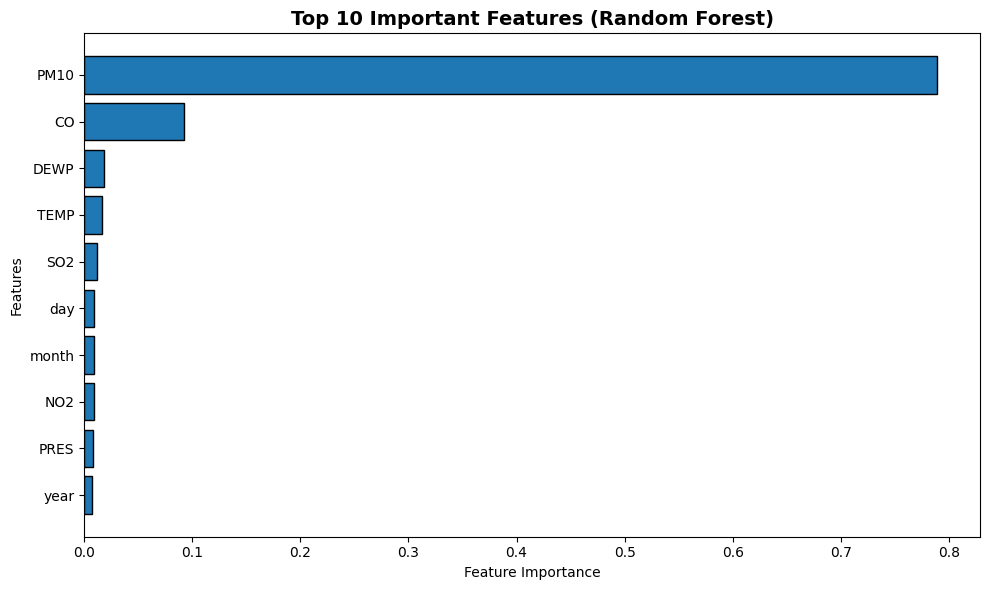

In [44]:
# ============================================================
# 6.6 Feature Importance Analysis
# ============================================================

import pandas as pd                          # For handling tabular data
import matplotlib.pyplot as plt              # For plotting charts

# Create DataFrame of feature importance
feature_importance = pd.DataFrame({          # Build DataFrame with features + importance
    'Feature': X_train.columns,              # Column names (predictor variables)
    'Importance': rf_model.feature_importances_  # Importance scores from Random Forest
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',                         # Sort by importance values
    ascending=False                          # Highest importance first
)

# Reset index
feature_importance.reset_index(drop=True, inplace=True)  # Reset index after sorting

# Display Top 10 Features
print("="*60)                                # Divider line
print("TOP 10 MOST IMPORTANT FEATURES")      # Section header
print("="*60)

display(feature_importance.head(10))         # Show top 10 most important predictors

# Plot
plt.figure(figsize=(10,6))                   # Set figure size

plt.barh(                                    # Horizontal bar chart
    feature_importance['Feature'].head(10)[::-1],   # Top 10 features (reverse order for top at top)
    feature_importance['Importance'].head(10)[::-1],# Corresponding importance values
    edgecolor='black'                        # Outline bars
)

plt.xlabel("Feature Importance")             # X-axis label
plt.ylabel("Features")                       # Y-axis label
plt.title(                                   # Chart title
    "Top 10 Important Features (Random Forest)",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()                           # Adjust layout
plt.show()                                   # Display plot


### **Interpretation:**

* The feature importance analysis identified **PM10** as the most influential predictor of **PM2.5** concentrations, with an importance score of **0.7894**. This indicates that PM10 contributed the most to the Random Forest model's predictions.

* **CO** was the second most important predictor, with an importance score of **0.0925**, suggesting that carbon monoxide also played a significant role in predicting PM2.5 concentrations.

* Meteorological variables, including **DEWP**, **TEMP**, and **PRES**, contributed to the model, although their importance scores were considerably lower than those of the major air pollutants.

* Other variables such as **SO2**, **NO2**, **day**, **month**, and **year** had relatively small importance scores, indicating that they contributed less to the model's predictive performance.

### **Overall Observation**

* The feature importance analysis indicates that **air pollutant variables**, particularly **PM10**, were the strongest contributors to predicting PM2.5 concentrations, while **meteorological** and **temporal** variables provided additional but comparatively smaller contributions. These findings suggest that pollutant measurements were more informative than weather and calendar-related variables for predicting PM2.5 concentrations in this dataset.

## **6.7 SHAP Analysis**

* **SHAP (SHapley Additive exPlanations)** was used to improve the interpretability of the best-performing machine learning model, the Random Forest Regressor. SHAP values quantify the contribution of each predictor variable to individual model predictions, providing insights into how environmental and meteorological factors contribute to the model's predictions of PM2.5 concentrations.

* Due to the large size of the dataset and the computational complexity of SHAP for ensemble models, the analysis was performed on a representative random sample of **20 observations** from the test dataset. This approach reduces computational cost while providing an interpretable visualization of feature contributions.


SHAP EXPLAINABILITY


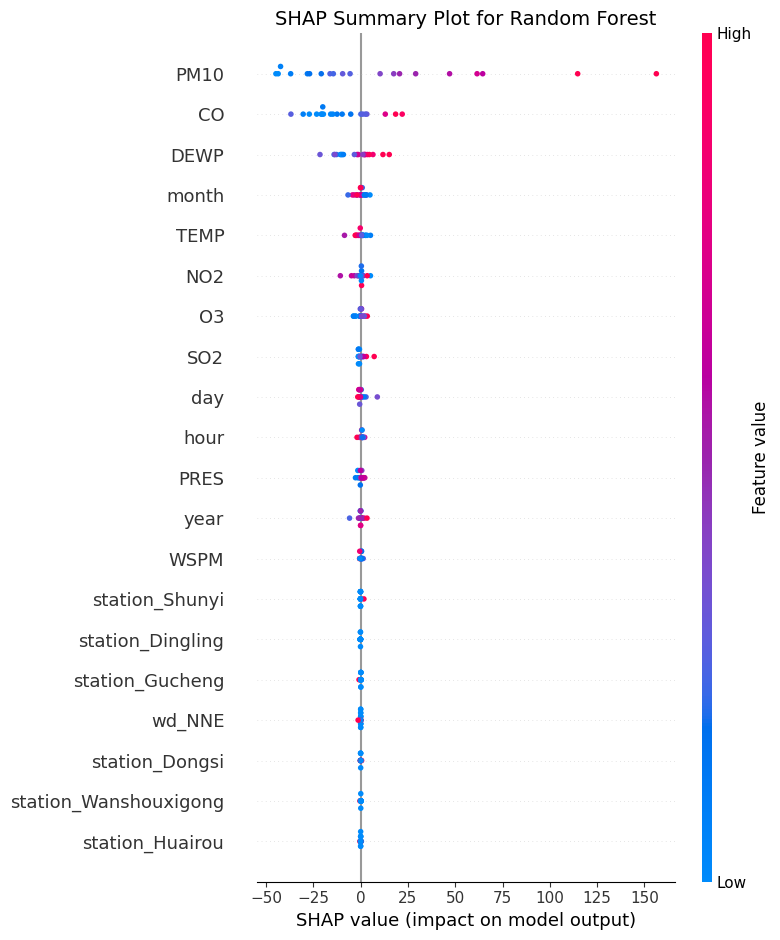

In [45]:
# ============================================================
# 6.7 SHAP Explainability
# ============================================================

# Install SHAP (Run once)
!pip install -q shap

import shap
import matplotlib.pyplot as plt

print("="*60)
print("SHAP EXPLAINABILITY")
print("="*60)

# ------------------------------------------------------------
# Create SHAP Explainer
# ------------------------------------------------------------
explainer = shap.TreeExplainer(rf_model)                    # Build SHAP explainer for Random Forest

# ------------------------------------------------------------
# Use a manageable sample
# ------------------------------------------------------------
X_sample = X_test.sample(n=20, random_state=42)             # Take small sample for visualization

# ------------------------------------------------------------
# Compute SHAP Values
# ------------------------------------------------------------
shap_values = explainer.shap_values(X_sample)               # Calculate SHAP values for sample

# ------------------------------------------------------------
# SHAP Summary Plot (Beeswarm)
# ------------------------------------------------------------
plt.figure(figsize=(10,6))

shap.summary_plot(                                          # Beeswarm plot of SHAP values
    shap_values,                                            # SHAP values
    X_sample,                                               # Corresponding features
    show=False                                              # Prevent auto-display
)

plt.title("SHAP Summary Plot for Random Forest", fontsize=14)

plt.tight_layout()
plt.show()


### **Interpretation:**

* The SHAP summary plot ranks the predictor variables according to their overall contribution to the Random Forest model's predictions.

* **PM10** has the greatest influence on the model predictions, as it exhibits the widest spread of SHAP values. This indicates that variations in PM10 have the largest impact on the predicted PM2.5 concentrations.

* **CO** is the second most influential predictor, followed by **DEWP**, **TEMP**, and **NO2**, indicating that these variables also contribute meaningfully to the model predictions.

* Features such as **O3**, **SO2**, **PRES**, **WSPM**, and the station-related variables have relatively small SHAP value ranges, indicating comparatively lower contributions to the model predictions.

* The colour gradient represents the magnitude of the feature values, where **red** indicates higher feature values and **blue** indicates lower feature values. The position of each point along the horizontal axis represents whether that feature increases or decreases the predicted PM2.5 concentration for an individual observation.

### **Overall Observation**

* The SHAP analysis confirms the findings of the Random Forest feature importance analysis, with **PM10** and **CO** emerging as the most influential predictors of PM2.5 concentrations. The results also demonstrate that both pollutant and meteorological variables contribute to the model predictions, although their relative importance varies across individual observations.

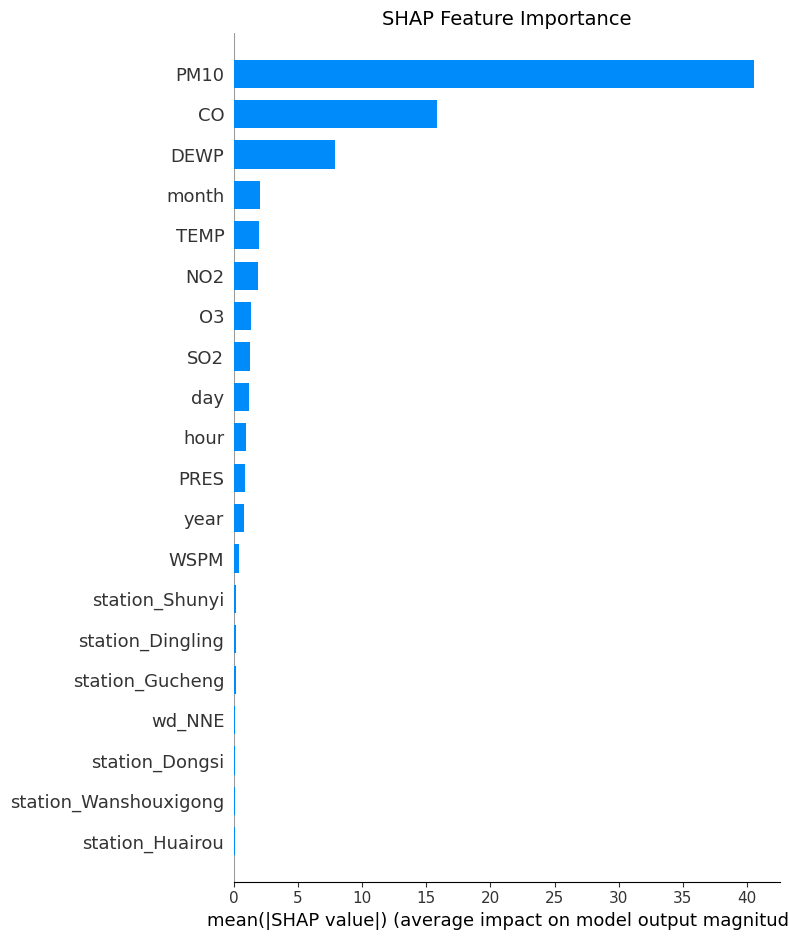

In [46]:
# ============================================================
# SHAP Feature Importance (Bar Plot)
# ============================================================

plt.figure(figsize=(10,6))                          # Set figure size

shap.summary_plot(                                  # Create SHAP bar plot
    shap_values,                                    # SHAP values from explainer
    X_sample,                                       # Corresponding features
    plot_type="bar",                                # Bar chart instead of beeswarm
    show=False                                      # Prevent auto-display
)

plt.title("SHAP Feature Importance", fontsize=14)   # Add title

plt.tight_layout()                                  # Adjust layout
plt.show()                                          # Display plot


### **Interpretation:**

* The SHAP feature importance plot ranks the predictor variables according to their **average absolute SHAP values**, which represent the average magnitude of each feature's contribution to the Random Forest model predictions.

* **PM10** is the most influential predictor, with the highest mean absolute SHAP value. This indicates that PM10 has the greatest overall impact on predicting PM2.5 concentrations across the analysed observations.

* **CO** is the second most important feature, followed by **DEWP**, suggesting that these variables also contribute substantially to the model predictions.

* Meteorological variables such as **TEMP**, **PRES**, and **WSPM**, together with temporal variables (**year**, **month**, **day**, and **hour**), contribute to the predictions but have considerably lower average impacts than the major pollutant variables.

* The encoded **station** and **wind direction** variables exhibit the smallest SHAP values, indicating that they have relatively limited influence on the model predictions compared with the pollutant and meteorological variables.

### **Overall Observation**

* The SHAP feature importance results reinforce the findings of both the Random Forest feature importance analysis and the SHAP summary plot. Across all three analyses, **PM10** consistently emerged as the most influential predictor, followed by **CO** and **DEWP**. This consistency increases confidence in the interpretation of the Random Forest model and demonstrates that pollutant-related variables contributed more strongly to PM2.5 prediction than meteorological, temporal, or location-based variables in this study.

## **6.8 Model Performance Comparison**

MODEL PERFORMANCE COMPARISON


,Rank,Model,MAE,RMSE,R²
0,1,Random Forest,10.13,17.83,0.9503
1,2,XGBoost,12.77,20.72,0.9330
2,3,Gradient Boosting,15.89,25.40,0.8993
3,4,Decision Tree,13.81,25.72,0.8967
4,5,Linear Regression,20.52,31.79,0.8422


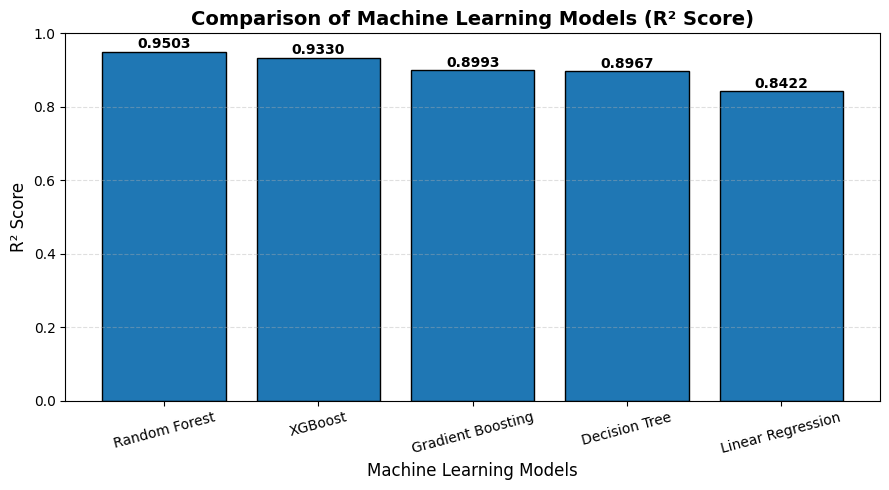


BEST PERFORMING MODEL
Rank  : 1
Model : Random Forest
MAE   : 10.13
RMSE  : 17.83
R²    : 0.9503

Interpretation:
The Random Forest achieved the highest R² score (0.9503) and was therefore selected as the best-performing model for predicting PM2.5 concentrations.


In [47]:
# ============================================================
# 6.8 Model Performance Comparison
# ============================================================

import pandas as pd                          # For handling tabular data
import matplotlib.pyplot as plt              # For plotting charts

# ------------------------------------------------------------
# Create Comparison Table
# ------------------------------------------------------------
results = pd.DataFrame({                     # Build a DataFrame to store metrics
    'Model': [                               # Column of model names
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'Gradient Boosting'
    ],
    'MAE': [lr_mae, dt_mae, rf_mae, xgb_mae, gb_mae],       # Mean Absolute Error values
    'RMSE': [lr_rmse, dt_rmse, rf_rmse, xgb_rmse, gb_rmse], # Root Mean Squared Error values
    'R²': [lr_r2, dt_r2, rf_r2, xgb_r2, gb_r2]               # R² scores
})

results = results.round({'MAE': 2, 'RMSE': 2, 'R²': 4})     # Round metrics for neat display

results = results.sort_values(by='R²', ascending=False)     # Sort models by R² (best first)
results = results.reset_index(drop=True)                    # Reset index after sorting
results.insert(0, 'Rank', range(1, len(results)+1))          # Add Rank column starting at 1

print("="*65)                                               # Print divider
print("MODEL PERFORMANCE COMPARISON")                       # Section header
print("="*65)

display(results)                                            # Show comparison table

results.to_csv("Model_Performance_Comparison.csv", index=False) # Save table to CSV file

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
plt.figure(figsize=(9,5))                                   # Set figure size

bars = plt.bar(                                             # Create bar chart
    results["Model"],                                       # Models on x-axis
    results["R²"],                                          # R² scores on y-axis
    edgecolor="black"                                       # Outline bars
)

plt.title("Comparison of Machine Learning Models (R² Score)", # Chart title
          fontsize=14, fontweight="bold")
plt.xlabel("Machine Learning Models", fontsize=12)          # X-axis label
plt.ylabel("R² Score", fontsize=12)                         # Y-axis label
plt.ylim(0,1)                                               # Limit y-axis between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.4)               # Add horizontal gridlines

for bar in bars:                                            # Annotate each bar
    height = bar.get_height()                               # Get bar height (R² value)
    plt.text(bar.get_x() + bar.get_width()/2,               # Place text at bar center
             height + 0.01,                                 # Slightly above bar
             f"{height:.4f}",                               # Format R² to 4 decimals
             ha='center', fontsize=10, fontweight='bold')

plt.xticks(rotation=15)                                     # Rotate x-axis labels
plt.tight_layout()                                          # Adjust layout
plt.show()                                                  # Display plot

# ------------------------------------------------------------
# Best Performing Model
# ------------------------------------------------------------
best_model = results.iloc[0]                                # Select top-ranked model

print("\n" + "="*65)
print("BEST PERFORMING MODEL")
print("="*65)

print(f"Rank  : {best_model['Rank']}")                      # Print rank
print(f"Model : {best_model['Model']}")                     # Print model name
print(f"MAE   : {best_model['MAE']}")                       # Print MAE
print(f"RMSE  : {best_model['RMSE']}")                      # Print RMSE
print(f"R²    : {best_model['R²']}")                        # Print R²

print("\nInterpretation:")                                  # Add interpretation
print(
    f"The {best_model['Model']} achieved the highest R² score "
    f"({best_model['R²']:.4f}) and was therefore selected as the "
    "best-performing model for predicting PM2.5 concentrations."
)


### **Note:** The machine learning models were evaluated using three performance metrics: **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **Coefficient of Determination (R²)**.

### The **Random Forest Regressor** achieved the **lowest MAE**, **lowest RMSE**, and **highest R² score**, and was therefore identified as the best-performing model.

### **Interpretation:**

* The performance comparison demonstrates that the **Random Forest Regressor** achieved the best overall predictive performance among the five machine learning models evaluated.

* The Random Forest model produced the **lowest Mean Absolute Error (MAE = 10.13 µg/m³)** and **Root Mean Squared Error (RMSE = 17.83 µg/m³)**, indicating the smallest prediction errors among all models.

* The model also achieved the **highest coefficient of determination (R² = 0.9503)**, indicating that approximately **95.03%** of the variability in PM2.5 concentrations was explained by the predictor variables.

* **XGBoost** ranked second, followed by **Gradient Boosting**, **Decision Tree**, and **Linear Regression**, demonstrating progressively lower predictive performance.

### **Overall Observation**

* Based on the evaluation metrics (**MAE, RMSE, and R²**), the **Random Forest Regressor** was identified as the most accurate and reliable model for predicting PM2.5 concentrations. Its superior performance indicates that the ensemble learning approach effectively captured the complex relationships among the pollutant, meteorological, temporal, and location-related variables in the dataset.

# **Results and Discussion**

The performance of five machine learning models, namely **Linear Regression, Decision Tree, Random Forest, XGBoost, and Gradient Boosting**, was evaluated using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and the **coefficient of determination (R²)**. The results showed that the **Random Forest Regressor** achieved the best overall predictive performance among the five evaluated models.

* **Random Forest Regressor** achieved the highest predictive performance with an **R² score of 0.9503**, an **MAE of 10.13 µg/m³**, and an **RMSE of 17.83 µg/m³**, indicating the highest predictive accuracy and the lowest prediction errors.

* **XGBoost** ranked second with an **R² score of 0.9330**, demonstrating strong predictive capability but slightly lower accuracy than the Random Forest model.

* **Gradient Boosting** and **Decision Tree** achieved **R² scores of 0.8993** and **0.8967**, respectively, providing good predictive performance while performing below the two best-performing ensemble models.

* **Linear Regression** recorded the lowest **R² score (0.8422)**, indicating that a simple linear model was less effective in modelling the relationships between the predictor variables and PM2.5 concentrations.

### **Overall Observation**

The results demonstrate that the **ensemble learning models** outperformed both the **Decision Tree** and **Linear Regression** models in predicting PM2.5 concentrations. Based on its superior performance across all evaluation metrics (**MAE, RMSE, and R²**), the **Random Forest Regressor** was selected as the final predictive model for this study.



# **Conclusion**

## Conclusion

This study developed and evaluated five machine learning algorithms, namely **Linear Regression, Decision Tree, Random Forest, XGBoost, and Gradient Boosting**, to predict **PM2.5** concentrations using pollutant, meteorological, temporal, and location-related variables from the **Beijing Multi-Site Air Quality Dataset**.

Among the evaluated models, the **Random Forest Regressor** demonstrated the highest predictive performance, achieving an **R² score of 0.9503**, an **MAE of 10.13 µg/m³**, and an **RMSE of 17.83 µg/m³**. These results indicate that, among the evaluated models, the Random Forest model provided the most accurate predictions and effectively modelled the complex relationships between the predictor variables and PM2.5 concentrations.

The developed predictive model has the potential to support **air quality monitoring**, **air pollution forecasting**, and **evidence-based environmental decision-making** by providing accurate predictions of **PM2.5** concentrations.

Future research may explore **deep learning techniques**, **additional environmental, traffic, land-use, and socio-economic variables**, and **real-time data integration** to further enhance prediction accuracy and improve the applicability of predictive air quality models.
